In [1]:
from copy import deepcopy
from scipy import stats
from scipy.spatial import cKDTree
import pandas as pd
import os
import numpy as np
from tqdm import tqdm
import networkx as nx
import random
from collections import defaultdict, Counter
from typing import Dict, List, Set, Tuple, Optional
from itertools import chain, product
import bisect
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")
seed = 0 # 1729928109

# Set the random seed for reproducibility
random.seed(seed)
np.random.seed(seed)

base_sparsified_path = r'/raid/t2/TGN_adv/sparsified_data'
dataset_name = 'wikipedia'

is_bipartite = True

if dataset_name.lower() in ['wikipedia', 'mooc']:
    is_bipartite = True
else:
    is_bipartite=False

original_filename = rf'ml_{dataset_name}.csv'

print(os.path.join(base_sparsified_path, dataset_name, original_filename))

orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset_name, original_filename))
orig_df.drop(['Unnamed: 0'], axis=1, inplace=True)
orig_df.head()

/raid/t2/TGN_adv/sparsified_data/wikipedia/ml_wikipedia.csv


,u,i,ts,label,idx
0,1,8228,0.0,0.0,1
1,2,8229,36.0,0.0,2
2,2,8229,77.0,0.0,3
3,3,8230,131.0,0.0,4
4,2,8229,150.0,0.0,5


In [2]:
val_ratio = test_ratio = 0.15

val_time, test_time = list(np.quantile(orig_df.ts, [(1 - val_ratio - test_ratio), (1 - test_ratio)]))

orig_df = orig_df[orig_df['ts'] < val_time]

In [3]:
# sparsification 
sprs_type = 'ts_tpr_remove_cosine'
upto = 0.7

sprs_filename = f'{dataset_name}_{sprs_type}_sparsified_{upto}.csv'
sprs_filename

full_sprs_filepath = os.path.join(base_sparsified_path, dataset_name, sprs_type, sprs_filename)

sprs_df = pd.read_csv(full_sprs_filepath)
# sprs_df.drop(['Unnamed: 0'], axis=1, inplace=True)
sprs_df.head()

,Unnamed: 0,u,i,ts,label,idx
0,0,1,8228,0,0.0,1
1,1,2,8229,36,0.0,2
2,2,2,8229,77,0.0,3
3,3,3,8230,131,0.0,4
4,4,2,8229,150,0.0,5


In [4]:
print(orig_df['ts'].min(), orig_df['ts'].max())

print(sum(orig_df['ts'].isna()), len(orig_df['ts'].unique()), len(orig_df['ts']), len(orig_df['ts']) - orig_df['ts'].nunique())

0.0 1862652.0
0 106926 110232 3306


## Helper Function

In [5]:
def calculate_node_degrees(df):
    """Calculates the degree for source and destination nodes separately."""
    src_degrees = Counter(df['u'])
    dst_degrees = Counter(df['i'])
    return src_degrees, dst_degrees

def calculate_non_bipartite_node_degrees(df: pd.DataFrame, 
                                         node_col1: str = 'u', 
                                         node_col2: str = 'i') -> Counter:
    """
    Calculates the total degree for each node in a non-bipartite graph.
    Assumes the graph is undirected for degree calculation purposes.
    Self-loops (e.g., an edge from node A to node A) are counted twice 
    towards the degree of node A.

    Args:
        df: Pandas DataFrame where each row represents an edge.
        node_col1: Name of the first column representing nodes in an edge.
        node_col2: Name of the second column representing nodes in an edge.

    Returns:
        A collections.Counter object mapping each node ID to its total degree.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input 'df' must be a Pandas DataFrame.")
    if node_col1 not in df.columns:
        raise ValueError(f"Column '{node_col1}' not found in DataFrame.")
    if node_col2 not in df.columns:
        raise ValueError(f"Column '{node_col2}' not found in DataFrame.")

    # Initialize a Counter to store degrees
    node_degrees = Counter()

    # Add occurrences from the first node column
    node_degrees.update(df[node_col1])
    
    node_degrees.update(df[node_col2])
    
    return node_degrees

def check_c3_compliance(df, negative_samples, W=1200):
    df_sorted = df.sort_values('ts')
    compliant = []
    for u, i, ts in negative_samples:
        # Find insertion point index
        insert_idx = df_sorted[df_sorted['ts'] <= ts].shape[0]
        # Get previous W edges
        window_start_idx = max(0, insert_idx - W)
        window_df = df_sorted.iloc[window_start_idx:insert_idx]
        # Get valid nodes from window
        nodes_in_window = set(window_df['u']) | set(window_df['i'])
        compliant.append((u in nodes_in_window) and (i in nodes_in_window))
    return compliant


def get_nodes_in_time_window(df: pd.DataFrame, current_time: float, window: int) -> Set[int]:
    """
    Get the set of nodes that were active within the time window before current_time.
    
    Args:
    df (pd.DataFrame): DataFrame with interactions ('u' for source, 'i' for destination, 'ts' for timestamp)
    current_time (float): Current timestamp
    window (int): Time window size
    
    Returns:
    Set[int]: Set of nodes active within the time window
    """
    window_start = max(current_time - window, df['ts'].min())
    window_df = df[(df['ts'] >= window_start) & (df['ts'] <= current_time)]
    return set(window_df['u']) | set(window_df['i'])

class Old_TemporalSampler:
    def __init__(self, original_graph, seed=None, time_window=1200):
        self.original_graph = original_graph
        self.seed=seed
        self.rng = np.random.default_rng(seed)
        self.time_window = time_window
        self.min_time = min(0, original_graph['ts'].min())
        self.max_time = original_graph['ts'].max()
        self.initialize_kde()
        self.initialize_kd_tree()

    def initialize_kde(self):
        df_sorted = self.original_graph.sort_values('ts')
        inter_event_times = np.diff(df_sorted['ts'])
        self.kde = stats.gaussian_kde(inter_event_times)
        # Set the random state for KDE
        # self.kde.set_bandwidth(bw_method=self.kde.factor)
        # self.kde.reseed(self.seed)

    def initialize_kd_tree(self):
        self.temporal_kd_tree = cKDTree(self.original_graph['ts'].values.reshape(-1, 1))

    def assign_timestamps(self, num_samples):
        kde_samples = self.kde.resample(num_samples, self.rng)[0]
        cumulative_times = np.cumsum(kde_samples) + self.min_time
        cumulative_times = np.clip(cumulative_times, self.min_time, self.max_time)
        jitter = self.rng.uniform(0, self.time_window * 0.1, num_samples)
        sampled_timestamps = cumulative_times + jitter
        sampled_timestamps.sort()
        sampled_timestamps = np.clip(sampled_timestamps, self.min_time, self.max_time)
        return sampled_timestamps

    def find_next_events(self, timestamps):
        _, indices = self.temporal_kd_tree.query(timestamps.reshape(-1, 1), k=1)
        return self.original_graph['ts'].values[indices]

def create_node_mapping(original_degrees: Dict[int, int], generated_degrees: Dict[int, int]) -> Dict[int, int]:
    """
    Create a one-to-one mapping between generated and original nodes based on degree.
    
    Args:
    original_degrees (Dict[int, int]): Degree distribution of original nodes
    generated_degrees (Dict[int, int]): Degree distribution of generated nodes
    
    Returns:
    Dict[int, int]: Mapping from generated nodes to original nodes
    """
    degree_to_nodes = defaultdict(list)
    for node, degree in original_degrees.items():
        degree_to_nodes[degree].append(node)
    
    generated_degree_to_nodes = defaultdict(list)
    for node, degree in generated_degrees.items():
        generated_degree_to_nodes[degree].append(node)
    
    mapping = {}
    for degree, nodes in degree_to_nodes.items():
        generated_nodes = generated_degree_to_nodes.get(degree, [])
        for original_node, generated_node in zip(nodes, generated_nodes):
            mapping[generated_node] = original_node
    
    return mapping

In [6]:
class TemporalSampler:
    def __init__(self, original_graph, seed=None, time_window=1200, 
                 num_bins=100, min_activity_threshold=2):
        """
        Enhanced Temporal Sampler with activity awareness and adaptive sampling
        
        Args:
            original_graph: DataFrame with 'ts', 'u', 'i' columns
            seed: Random seed
            time_window: Time window size for node availability
            num_bins: Number of temporal bins for activity analysis
            min_activity_threshold: Minimum number of nodes required in a time period
        """
        self.original_graph = original_graph
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.time_window = time_window
        self.num_bins = num_bins
        self.min_activity_threshold = min_activity_threshold
        
        # Time bounds
        self.min_time = min(0, original_graph['ts'].min())
        self.max_time = original_graph['ts'].max()
        self.time_range = self.max_time - self.min_time
        
        # Initialize components
        self._compute_activity_density()
        self._initialize_kde()
        self._initialize_node_windows()
        
    def _compute_activity_density(self):
        """Compute temporal activity density and identify active periods"""
        # Create temporal bins
        self.bin_edges = np.linspace(self.min_time, self.max_time, self.num_bins + 1)
        self.bin_width = (self.max_time - self.min_time) / self.num_bins
        
        # Compute activity density
        df_sorted = self.original_graph.sort_values('ts')
        hist, _ = np.histogram(df_sorted['ts'], bins=self.bin_edges)
        self.activity_density = hist / hist.sum()
        
        # Track node activities
        self.src_activity = defaultdict(list)
        self.dst_activity = defaultdict(list)
        
        for _, row in df_sorted.iterrows():
            bin_idx = np.searchsorted(self.bin_edges, row['ts']) - 1
            if bin_idx < self.num_bins:
                self.src_activity[row['u']].append(bin_idx)
                self.dst_activity[row['i']].append(bin_idx)
        
        # Identify active periods
        self.active_bins = np.where(hist >= self.min_activity_threshold)[0]
        self.active_periods = self._merge_active_periods()
        
    def _merge_active_periods(self):
        """Merge consecutive active periods"""
        if len(self.active_bins) == 0:
            return []
            
        periods = []
        start = self.active_bins[0]
        prev = start
        
        for bin_idx in self.active_bins[1:]:
            if bin_idx - prev > 1:
                periods.append((
                    self.bin_edges[start],
                    self.bin_edges[prev + 1]
                ))
                start = bin_idx
            prev = bin_idx
            
        periods.append((
            self.bin_edges[start],
            self.bin_edges[prev + 1]
        ))
        
        return periods
        
    def _initialize_kde(self):
        """Initialize adaptive KDE with local bandwidth"""
        df_sorted = self.original_graph.sort_values('ts')
        inter_event_times = np.diff(df_sorted['ts'])
        
        # Compute local density for adaptive bandwidth
        local_density = []
        window_size = len(inter_event_times) // 20  # 5% of data
        
        for i in range(len(inter_event_times)):
            start_idx = max(0, i - window_size//2)
            end_idx = min(len(inter_event_times), i + window_size//2)
            local_density.append(len(inter_event_times[start_idx:end_idx]))
            
        local_density = np.array(local_density)
        self.bandwidths = 1 / np.sqrt(local_density + 1)  # Adaptive bandwidth
        
        # Initialize KDE with adaptive bandwidth
        self.kde = stats.gaussian_kde(
            inter_event_times,
            bw_method=np.mean(self.bandwidths)
        )
        
    def _initialize_node_windows(self):
        """Track node availability windows"""
        df_sorted = self.original_graph.sort_values('ts')
        self.node_windows = defaultdict(list)
        
        window_starts = df_sorted['ts'].values
        window_ends = window_starts + self.time_window
        
        for ts, u, i in df_sorted[['ts', 'u', 'i']].values:
            self.node_windows[u].append((ts, ts + self.time_window))
            self.node_windows[i].append((ts, ts + self.time_window))
            
        # Merge overlapping windows
        for node in self.node_windows:
            merged = []
            current = None
            
            for window in sorted(self.node_windows[node]):
                if current is None:
                    current = list(window)
                elif window[0] <= current[1]:
                    current[1] = max(current[1], window[1])
                else:
                    merged.append(tuple(current))
                    current = list(window)
                    
            if current is not None:
                merged.append(tuple(current))
                
            self.node_windows[node] = merged

    def assign_timestamps(self, num_samples):
        """
        Assign timestamps using activity-aware sampling
        """
        sampled_timestamps = []
        required_samples = num_samples
        
        # Sample from active periods with higher probability
        while len(sampled_timestamps) < required_samples:
            # Choose active period weighted by activity density
            period_weights = [
                np.sum(self.activity_density[
                    np.searchsorted(self.bin_edges, start):
                    np.searchsorted(self.bin_edges, end)
                ])
                for start, end in self.active_periods
            ]
            period_weights = np.array(period_weights) / np.sum(period_weights)
            
            chosen_period = self.active_periods[
                self.rng.choice(len(self.active_periods), p=period_weights)
            ]
            
            # Sample timestamps within chosen period
            local_samples = min(
                required_samples - len(sampled_timestamps),
                max(1, int(required_samples * period_weights[0]))
            )
            
            # Generate samples using KDE
            kde_samples = self.kde.resample(local_samples, self.rng)[0]
            timestamps = np.cumsum(kde_samples) + chosen_period[0]
            timestamps = timestamps[timestamps <= chosen_period[1]]
            
            # Add jitter while maintaining window constraints
            jitter = self.rng.uniform(
                -self.time_window * 0.05,
                self.time_window * 0.05,
                len(timestamps)
            )
            timestamps += jitter
            
            # Ensure timestamps are within bounds
            timestamps = np.clip(timestamps, self.min_time, self.max_time)
            sampled_timestamps.extend(timestamps)
            
        sampled_timestamps = np.array(sorted(sampled_timestamps[:num_samples]))
        return sampled_timestamps
        
    def get_activity_metrics(self):
        """Return activity metrics for analysis"""
        return {
            'activity_density': self.activity_density,
            'active_periods': self.active_periods,
            'bin_edges': self.bin_edges,
            'total_active_bins': len(self.active_bins)
        }

In [7]:
class BPOnly_EdgeTimestampSelector:
   def __init__(self,
                feasible_edges_dict: Dict[Tuple[int, int], List[int]],
                original_df: pd.DataFrame,
                degree_dict: Dict[int, int],
                removed_edges: Set[Tuple[int, int]],
                src_nodes: Optional[Set[int]] = None,
                dst_nodes: Optional[Set[int]] = None,
                time_window: int = 1200
                ):
       self.feasible_edges_dict = feasible_edges_dict
       self.original_df = original_df
       self.degree_dict = degree_dict
       self.removed_edges = removed_edges
       self.is_bipartite = src_nodes is not None and dst_nodes is not None
       self.src_nodes: Set[int] = src_nodes if src_nodes is not None else set()
       self.dst_nodes: Set[int] = dst_nodes if dst_nodes is not None else set()
       self.time_window = time_window
       
       self.node_usage: Dict[int, int] = defaultdict(int)
       self.selected_pairs: List[Tuple[int, int, int]] = []
       self.remaining_capacity: Dict[int, int] = deepcopy(degree_dict)
       
       self.max_edges: int = self._calculate_edge_budget()
       self.node_to_edges: Dict[int, List[Tuple[int, int]]] = self._create_node_edge_mapping()
       self.feasible_adj_lists: Dict[int, Set[int]] = self._create_adj_lists()
       
       TotalDegree_Src_Negative = sum(self.degree_dict.get(s, 0) for s in self.src_nodes if s in self.degree_dict)
       TotalDegree_Dst_Negative = sum(self.degree_dict.get(d, 0) for d in self.dst_nodes if d in self.degree_dict)
       True_Max_Possible_Edges = min(TotalDegree_Src_Negative, TotalDegree_Dst_Negative)
       
       print(f'{True_Max_Possible_Edges = } {self.max_edges = } {len(self.removed_edges) =}')
           
   def _calculate_edge_budget(self) -> int:
       if self.is_bipartite:
           if not self.src_nodes: return 0
           src_sum = sum(self.degree_dict.get(n, 0) for n in self.src_nodes)
           return src_sum
       return sum(self.degree_dict.values()) // 2
       
   def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
       node_to_edges: Dict[int, List[Tuple[int, int]]] = defaultdict(list)
       for edge in self.feasible_edges_dict:
           u, v = int(edge[0]), int(edge[1])
           node_to_edges[u].append(edge)
           node_to_edges[v].append(edge)
       return node_to_edges

   def _create_adj_lists(self) -> Dict[int, Set[int]]:
       adj_lists: Dict[int, Set[int]] = defaultdict(set)
       for (u, v) in self.feasible_edges_dict:
           adj_lists[u].add(v)
           if not self.is_bipartite: 
               adj_lists[v].add(u)
       return adj_lists
       
   def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
       priority_nodes = sorted(
           [n for n in self.degree_dict if self.degree_dict.get(n,0) > 0],
           key=lambda x: (self.degree_dict.get(x,0), -len(self.node_to_edges.get(x, []))),
           reverse=True
       )
       
       selected_count = 0
       pbar = tqdm(total=self.max_edges, desc="Selecting edges (Initial)", leave=False, ncols=100, unit="edge")
       
       for node in priority_nodes:
           if selected_count >= self.max_edges: break
           if self.remaining_capacity.get(node, 0) <= 0: continue
               
           while self.remaining_capacity.get(node, 0) > 0 and selected_count < self.max_edges:
               candidates = self._get_candidates(node)
               if not candidates: break
                   
               scored_candidates = [
                   (self._calculate_score(edge, timestamps), edge, timestamps) 
                   for edge, timestamps in candidates
               ]
               scored_candidates.sort(reverse=True)
               
               selected_one_for_node_this_iteration = False
               for _score, edge, timestamps in scored_candidates:
                   if self._can_select(edge, timestamps): 
                       best_timestamp = self._pick_best_timestamp(timestamps, edge)
                       self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                       self._update_tracking(edge)
                       selected_count += 1
                       pbar.update(1)
                       selected_one_for_node_this_iteration = True
                       break 
                       
               if not selected_one_for_node_this_iteration: break 
       pbar.close()
       
       if selected_count < self.max_edges:
           print(f'\nInitial selection: {selected_count}/{self.max_edges} edges. Starting recovery phase...')
           remaining_needed = self.max_edges - selected_count
           
           recovery_pbar = tqdm(total=remaining_needed, desc="Selecting edges (Recovery)", leave=False, ncols=100, unit="edge")
           self._fast_recovery_phase(remaining_needed, self.original_df, recovery_pbar)
           recovery_pbar.close()
           print(f'Recovery phase complete. Total selected: {len(self.selected_pairs)}/{self.max_edges}')
       
       self._validate_selections()
       return self.selected_pairs
   
   def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame, pbar: tqdm):
       """
       Recovery phase to find additional negative samples, respecting C3-like compliance.
       Allows the same (u,v) pair to be selected multiple times if different C3-compliant
       timestamps are found, and nodes have capacity. Prioritizes nodes with larger degree deficits.
       """
       additional_edges_added_in_recovery = 0
       
       df_sorted = original_df.sort_values('ts').set_index('ts')
       node_appearances: Dict[int, List[float]] = defaultdict(list)
       for ts_idx, row in df_sorted.iterrows():
           ts_val = float(ts_idx)
           node_appearances[row['u']].append(ts_val)
           if 'i' in row: node_appearances[row['i']].append(ts_val)
           elif 'v' in row: node_appearances[row['v']].append(ts_val)

       all_nodes_with_target_degree = self.degree_dict.keys()
       potential_src_candidates = self.src_nodes if self.is_bipartite else all_nodes_with_target_degree
       potential_dst_candidates = self.dst_nodes if self.is_bipartite else all_nodes_with_target_degree
       
       # These lists are dynamically pruned as nodes fill capacity
       available_src_nodes = [n for n in potential_src_candidates if self.remaining_capacity.get(n, 0) > 0]
       available_dst_nodes = [n for n in potential_dst_candidates if self.remaining_capacity.get(n, 0) > 0]

       # MODIFIED: Track selected (u,v,t) triplets
       current_selected_triplets: Set[Tuple[int, int, int]] = set(self.selected_pairs)
       
       all_timestamps = sorted(list(set(ts for ts_list in self.feasible_edges_dict.values() for ts in ts_list)))
       if not all_timestamps:
           print("\tWarning: No timestamps found in feasible_edges_dict for recovery phase.")
           return 

       window_cache: Dict[float, Set[int]] = {} 
       # Ensure time_window interpretation is correct for your 'ts' units
       # Assuming self.time_window is in seconds and original_df['ts'] is in milliseconds:
       window_size_val = self.time_window * 1000.0 
       # If self.time_window and original_df['ts'] are in the same units (e.g. seconds):
       # window_size_val = float(self.time_window)
       min_original_ts = float(df_sorted.index.min()) if not df_sorted.empty else 0.0

       # This set is updated if nodes are removed from available_src/dst_nodes
       active_nodes_for_cache_check = set(available_src_nodes) | set(available_dst_nodes)
       def get_nodes_in_window(timestamp: float) -> Set[int]:
           timestamp = float(timestamp) 
           if timestamp in window_cache: return window_cache[timestamp]
           window_start = max(timestamp - window_size_val, min_original_ts)
           nodes_in_window_result = set()
           for node in active_nodes_for_cache_check: 
               appearances = node_appearances.get(node, [])
               idx = bisect.bisect_left(appearances, window_start)
               if idx < len(appearances) and appearances[idx] <= timestamp:
                   nodes_in_window_result.add(node)
           window_cache[timestamp] = nodes_in_window_result
           return nodes_in_window_result

       batch_size = 200 
       newly_added_edges_in_recovery: List[Tuple[int, int, int]] = []
    #    random.shuffle(all_timestamps)  # TODO: Commenting out to maintain the temporality

       for i in range(0, len(all_timestamps), batch_size):
           if additional_edges_added_in_recovery >= needed_edges: break
           batch_ts_list = all_timestamps[i:i + batch_size]
           
           for ts_val in batch_ts_list: get_nodes_in_window(float(ts_val))
           
           for timestamp_candidate_float in batch_ts_list:
               timestamp_candidate = int(timestamp_candidate_float) # Assuming timestamps are int after all
               if additional_edges_added_in_recovery >= needed_edges: break
                   
               active_nodes_this_ts = window_cache[timestamp_candidate_float]
               
               current_available_src_still_needed = [n for n in available_src_nodes if self.remaining_capacity.get(n,0) > 0]
               current_available_dst_still_needed = [n for n in available_dst_nodes if self.remaining_capacity.get(n,0) > 0]

               current_valid_src = [n for n in current_available_src_still_needed if n in active_nodes_this_ts]
               current_valid_dst = [n for n in current_available_dst_still_needed if n in active_nodes_this_ts]
               
               src_deficits = {n: self.degree_dict.get(n, 0) - self.node_usage.get(n,0) for n in current_valid_src}
               dst_deficits = {n: self.degree_dict.get(n, 0) - self.node_usage.get(n,0) for n in current_valid_dst}
               current_valid_src.sort(key=lambda n: src_deficits.get(n, 0), reverse=True)
               current_valid_dst.sort(key=lambda n: dst_deficits.get(n, 0), reverse=True)

               for src_node in current_valid_src:
                   if additional_edges_added_in_recovery >= needed_edges: break
                   if self.remaining_capacity.get(src_node,0) <= 0: continue 

                   for dst_node in current_valid_dst:
                       if additional_edges_added_in_recovery >= needed_edges: break
                       if self.remaining_capacity.get(dst_node,0) <= 0: continue
                       
                       if not self.is_bipartite and src_node == dst_node: continue

                       edge_pair = (src_node, dst_node) 
                       current_triplet_to_check = (src_node, dst_node, timestamp_candidate)
                       
                       if current_triplet_to_check in current_selected_triplets: continue
                       if edge_pair in self.removed_edges: continue
                        
                       if self.is_bipartite:
                           if not (src_node in self.src_nodes and dst_node in self.dst_nodes): continue
                       
                       if self._can_select(edge_pair, [timestamp_candidate]): 
                           newly_added_edges_in_recovery.append(current_triplet_to_check)
                           self._update_tracking(edge_pair) 
                           current_selected_triplets.add(current_triplet_to_check) 
                           
                           additional_edges_added_in_recovery += 1
                           pbar.update(1)
                           
                           if self.remaining_capacity.get(src_node,0) <= 0:
                               if src_node in available_src_nodes: available_src_nodes.remove(src_node)
                               active_nodes_for_cache_check.discard(src_node)
                               break 
                           if self.remaining_capacity.get(dst_node,0) <= 0:
                               if dst_node in available_dst_nodes: available_dst_nodes.remove(dst_node)
                               active_nodes_for_cache_check.discard(dst_node)
                               
        #    window_cache.clear()   # TODO: Commenting Out
       
       self.selected_pairs.extend(newly_added_edges_in_recovery)

   def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
       candidates = []
       for edge in self.node_to_edges.get(node, []): 
           timestamps = self.feasible_edges_dict.get(edge)
           if not timestamps: continue
           other_node = self._get_other_node(edge, node)
           if self.remaining_capacity.get(other_node, 0) > 0:
               candidates.append((edge, timestamps))
       return candidates

   def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
       u, v = edge
       return v if node == u else u
       
   def _calculate_score(self, edge: Tuple[int, int], timestamps: List[int]) -> float:
       u, v = edge
       remaining_cap_u = self.remaining_capacity.get(u, 0)
       remaining_cap_v = self.remaining_capacity.get(v, 0)
       score = (remaining_cap_u + remaining_cap_v + 
               len(timestamps) - 
               (self.node_usage.get(u, 0) + self.node_usage.get(v, 0)) * 10.0)
       if remaining_cap_u > 0 and remaining_cap_v > 0: score += 50.0 
       return score
       
   def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
       u, v = edge
       if not timestamps: return False
       if self.remaining_capacity.get(u, 0) <= 0 or self.remaining_capacity.get(v, 0) <= 0: return False
       
       if self.is_bipartite:
           u_is_src = u in self.src_nodes; u_is_dst = u in self.dst_nodes
           v_is_src = v in self.src_nodes; v_is_dst = v in self.dst_nodes
           if (u_is_src and v_is_src) or (u_is_dst and v_is_dst): return False
           # Ensure edge connects one src to one dst. If nodes can be in NEITHER set, this is important.
           # if not ((u_is_src and v_is_dst) or (u_is_dst and v_is_src)): return False # This might be too strict if nodes can only be in one set or neither
       
       if edge in self.removed_edges: return False
       return True

   def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
       if not timestamps: raise ValueError(f"Cannot pick timestamp from empty list for edge {edge}")
    #    return int(random.choice(timestamps))   # 100% generation using this.
       return int(max(timestamps)) 

   def _update_tracking(self, edge: Tuple[int, int]):
       u, v = edge
       self.remaining_capacity[u] = self.remaining_capacity.get(u, 1) - 1
       self.remaining_capacity[v] = self.remaining_capacity.get(v, 1) - 1
       self.node_usage[u] = self.node_usage.get(u, 0) + 1
       self.node_usage[v] = self.node_usage.get(v, 0) + 1
       if self.remaining_capacity[u] < 0: self.remaining_capacity[u] = 0
       if self.remaining_capacity[v] < 0: self.remaining_capacity[v] = 0

   def _validate_selections(self):
       print("\n--- Validation ---")
       node_counts = defaultdict(int)
       unique_edge_triplets = set() # Now validating based on (u,v,t)
       
       for u_sel, v_sel, t_sel in self.selected_pairs:
           node_counts[u_sel] += 1
           node_counts[v_sel] += 1
           current_triplet = (u_sel, v_sel, t_sel)
           if current_triplet in unique_edge_triplets:
               print(f"\tERROR: Duplicate edge triplet selected: {current_triplet}") # Should not happen if logic is correct
           unique_edge_triplets.add(current_triplet)

       # Count unique (u,v) pairs to see pair diversity
       unique_edge_pairs = {(int(e[0]), int(e[1])) for e in self.selected_pairs}
       print(f"\tTotal unique (u,v) pairs selected: {len(unique_edge_pairs)}")
       print(f"\tTotal unique edges (u,v,t) selected: {len(self.selected_pairs)} (Budget was: {self.max_edges})")
       
       over_capacity_nodes = []
       for node, count in node_counts.items():
           target_degree = self.degree_dict.get(node, 0)
           if count > target_degree:
               over_capacity_nodes.append((node, count, target_degree))
       
       if over_capacity_nodes:
           print("\tERROR: Nodes selected over their target degree:")
           for node, count, target in over_capacity_nodes: print(f"\t  Node {node}: Selected {count}, Target {target}")
       else: print("\tAll selected node degrees are within or at target capacity.")

       if self.is_bipartite:
           src_nodes_in_selection = {n for n in node_counts if n in self.src_nodes}
           dst_nodes_in_selection = {n for n in node_counts if n in self.dst_nodes}
           num_src_total = len(self.src_nodes) if self.src_nodes else 0
           num_dst_total = len(self.dst_nodes) if self.dst_nodes else 0
           print(f"\tSource nodes used in selection: {len(src_nodes_in_selection)} / {num_src_total}")
           print(f"\tDestination nodes used in selection: {len(dst_nodes_in_selection)} / {num_dst_total}")
       
       for u_sel, v_sel, t_sel in self.selected_pairs:
           if (u_sel, v_sel) in self.removed_edges:
               print(f"\tERROR: Edge pair ({u_sel},{v_sel}) from removed_edges was selected with timestamp {t_sel}!")
       print("--- End Validation ---")

In [8]:
class EdgeTimestampSelector:
   def __init__(self,
                feasible_edges_dict: Dict[Tuple[int, int], List[float]], # Timestamps in lists can be float
                original_df: pd.DataFrame, # Full historical graph for C3 checks
                degree_dict: Dict[int, int],
                removed_edges: Set[Tuple[int, int]],
                src_nodes: Optional[Set[int]] = None,
                dst_nodes: Optional[Set[int]] = None,
                time_window: int = 1200,
                allow_self_loops_in_non_bipartite: bool = False, # Parameter for non-bipartite self-loops
                random_seed: Optional[int] = None
                ):

       # Standardize input node IDs to int and ensure dictionary keys are also int
       self.degree_dict = {int(k): v for k, v in degree_dict.items()}
       self.src_nodes: Set[int] = {int(n) for n in src_nodes} if src_nodes is not None else set()
       self.dst_nodes: Set[int] = {int(n) for n in dst_nodes} if dst_nodes is not None else set()
       
       self.feasible_edges_dict: Dict[Tuple[int,int], List[float]] = {
           (int(k[0]), int(k[1])): v for k,v in feasible_edges_dict.items()
       }
       # Ensure removed_edges also uses int tuples
       self.removed_edges: Set[Tuple[int,int]] = {(int(e[0]), int(e[1])) for e in removed_edges}

       self.original_df = original_df 
       self.is_bipartite = bool(self.src_nodes and self.dst_nodes) # True if both are non-empty
       self.time_window = time_window
       self.allow_self_loops_in_non_bipartite = allow_self_loops_in_non_bipartite

       if random_seed is not None:
           random.seed(random_seed)
       
       self.node_usage: Dict[int, int] = defaultdict(int)
       self.selected_pairs: List[Tuple[int, int, int]] = [] # Stores (int, int, int)
       self.selected_triplets_set: Set[Tuple[int, int, int]] = set() # Tracks unique (int,int,int)
       self.remaining_capacity: Dict[int, int] = deepcopy(self.degree_dict)
       
       self.max_edges: int = self._calculate_edge_budget()
       self.node_to_edges: Dict[int, List[Tuple[int, int]]] = self._create_node_edge_mapping()
       self.feasible_adj_lists: Dict[int, Set[int]] = self._create_adj_lists() # Currently unused

           
   def _calculate_edge_budget(self) -> int:
       if self.is_bipartite:
           # For bipartite, budget is often sum of one partition's degrees.
           # Caller should ensure consistency with min(sum_src, sum_dst) if hard limit is desired.
           src_sum = sum(self.degree_dict.get(n, 0) for n in self.src_nodes)
           return src_sum
       else: # Non-bipartite
           return sum(self.degree_dict.values()) // 2
       
   def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
       node_to_edges: Dict[int, List[Tuple[int, int]]] = defaultdict(list)
       for edge_pair_int in self.feasible_edges_dict: # Keys are already (int,int)
           node_to_edges[edge_pair_int[0]].append(edge_pair_int)
           node_to_edges[edge_pair_int[1]].append(edge_pair_int)
       return node_to_edges

   def _create_adj_lists(self) -> Dict[int, Set[int]]: # Currently unused
       adj_lists: Dict[int, Set[int]] = defaultdict(set)
       for u, v in self.feasible_edges_dict: # u,v are int
           adj_lists[u].add(v)
           if not self.is_bipartite: 
               adj_lists[v].add(u)
       return adj_lists
       
   def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
       # Nodes from degree_dict keys are int due to __init__
       priority_nodes = sorted(
           [n for n in self.degree_dict if self.degree_dict.get(n,0) > 0],
           key=lambda x: (self.degree_dict.get(x,0), -len(self.node_to_edges.get(x, []))),
           reverse=True
       )
       
       selected_count = 0
       pbar_total = max(0, self.max_edges)
       pbar = tqdm(total=pbar_total, desc="Selecting edges (Initial)", leave=False, ncols=100, unit="edge")
       
       for node in priority_nodes: # node is int
           if selected_count >= self.max_edges: break
           if self.remaining_capacity.get(node, 0) <= 0: continue
               
           while self.remaining_capacity.get(node, 0) > 0 and selected_count < self.max_edges:
               candidates = self._get_candidates(node) # List of ((int,int), List[float])
               if not candidates: break
                   
               scored_candidates = [
                   (self._calculate_score(edge_pair, ts_list), edge_pair, ts_list) 
                   for edge_pair, ts_list in candidates
               ]
               scored_candidates.sort(reverse=True)
               
               selected_one_for_node_this_iteration = False
               for _score, edge_pair_int, timestamps_float_list in scored_candidates:
                   if self._can_select(edge_pair_int, timestamps_float_list): 
                       best_timestamp_int = self._pick_best_timestamp(timestamps_float_list, edge_pair_int)
                       triplet_to_add = (edge_pair_int[0], edge_pair_int[1], best_timestamp_int)

                       if triplet_to_add not in self.selected_triplets_set: # Prevent duplicate triplets
                           self.selected_pairs.append(triplet_to_add)
                           self.selected_triplets_set.add(triplet_to_add)
                           self._update_tracking(edge_pair_int) 
                           selected_count += 1
                           pbar.update(1)
                           selected_one_for_node_this_iteration = True
                           break # Found a new unique triplet for this node's current capacity slot
                       # else: Triplet already selected, loop continues to next candidate for 'node'
                           
               if not selected_one_for_node_this_iteration: break 
       pbar.close()
       
       if selected_count < self.max_edges:
           print(f'\nInitial selection: {selected_count}/{self.max_edges} edges. Starting recovery phase...')
           remaining_needed = self.max_edges - selected_count
           if remaining_needed > 0:
                recovery_pbar_total = max(0, remaining_needed)
                recovery_pbar = tqdm(total=recovery_pbar_total, desc="Selecting edges (Recovery)", leave=False, ncols=100, unit="edge")
                self._fast_recovery_phase(remaining_needed, self.original_df, recovery_pbar)
                recovery_pbar.close()
                print(f'Recovery phase complete. Total selected: {len(self.selected_pairs)}/{self.max_edges}')
           # else: No recovery needed.
       
       self._validate_selections()
       return self.selected_pairs
   
   def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame, pbar: tqdm):
       additional_edges_added_in_recovery = 0
       
       df_sorted = original_df.sort_values('ts').set_index('ts')
       node_appearances: Dict[int, List[float]] = defaultdict(list)
       for ts_idx, row_series in df_sorted.iterrows():
           row = row_series.to_dict() if isinstance(row_series, pd.Series) else row_series
           ts_val = float(ts_idx)
           u_node = int(row['u'])
           node_appearances[u_node].append(ts_val)
           other_node_key = 'i' if 'i' in row else 'v'
           if other_node_key in row:
               i_node = int(row[other_node_key])
               node_appearances[i_node].append(ts_val)

       all_nodes_with_target_degree = self.degree_dict.keys() # Already int keys
       potential_src_candidates = self.src_nodes if self.is_bipartite else all_nodes_with_target_degree
       potential_dst_candidates = self.dst_nodes if self.is_bipartite else all_nodes_with_target_degree
       
       available_src_nodes = [n for n in potential_src_candidates if self.remaining_capacity.get(n, 0) > 0]
       available_dst_nodes = [n for n in potential_dst_candidates if self.remaining_capacity.get(n, 0) > 0]

       current_selected_triplets: Set[Tuple[int, int, int]] = set(self.selected_pairs)
       
       all_timestamps_float = sorted(list(set(ts for ts_list in self.feasible_edges_dict.values() for ts in ts_list)))
       if not all_timestamps_float:
           print("\tWarning: No timestamps found in feasible_edges_dict for recovery phase.")
           return 

       window_cache: Dict[float, Set[int]] = {} 
       window_size_val = self.time_window * 1000.0 
       min_original_ts = float(df_sorted.index.min()) if not df_sorted.empty else 0.0

       active_nodes_for_cache_check = set(available_src_nodes) | set(available_dst_nodes) # All nodes int
       def get_nodes_in_window(timestamp_float: float) -> Set[int]: # param is float for cache key & comparison
           if timestamp_float in window_cache: return window_cache[timestamp_float]
           window_start = timestamp_float - window_size_val
           if not df_sorted.empty: window_start = max(window_start, min_original_ts)
           nodes_in_window_result = set()
           for node in active_nodes_for_cache_check: # node is int
               appearances = node_appearances.get(node, []) # appearances are List[float]
               idx = bisect.bisect_left(appearances, window_start)
               if idx < len(appearances) and appearances[idx] <= timestamp_float:
                   nodes_in_window_result.add(node)
           window_cache[timestamp_float] = nodes_in_window_result
           return nodes_in_window_result

       batch_size = 200 
       newly_added_edges_in_recovery: List[Tuple[int, int, int]] = []
       if all_timestamps_float: random.shuffle(all_timestamps_float) # Shuffle if non-empty

       for i in range(0, len(all_timestamps_float), batch_size):
           if additional_edges_added_in_recovery >= needed_edges: break
           batch_ts_list_float = all_timestamps_float[i:i + batch_size]
           
           for ts_f in batch_ts_list_float: get_nodes_in_window(ts_f) 
           
           for timestamp_as_float in batch_ts_list_float:
               timestamp_candidate_int = int(round(timestamp_as_float)) # Use rounded int for selected edge
               if additional_edges_added_in_recovery >= needed_edges: break
                   
               active_nodes_this_ts = window_cache[timestamp_as_float]
               
               current_av_src = [n for n in available_src_nodes if self.remaining_capacity.get(n,0) > 0]
               current_av_dst = [n for n in available_dst_nodes if self.remaining_capacity.get(n,0) > 0]
               current_valid_src = [n for n in current_av_src if n in active_nodes_this_ts]
               current_valid_dst = [n for n in current_av_dst if n in active_nodes_this_ts]
               
               src_deficits = {n: self.degree_dict.get(n, 0) - self.node_usage.get(n,0) for n in current_valid_src}
               dst_deficits = {n: self.degree_dict.get(n, 0) - self.node_usage.get(n,0) for n in current_valid_dst}
               current_valid_src.sort(key=lambda n: src_deficits.get(n, 0), reverse=True)
               current_valid_dst.sort(key=lambda n: dst_deficits.get(n, 0), reverse=True)

               for src_node in current_valid_src: # src_node is int
                   if additional_edges_added_in_recovery >= needed_edges: break
                   if self.remaining_capacity.get(src_node,0) <= 0: continue 

                   for dst_node in current_valid_dst: # dst_node is int
                       if additional_edges_added_in_recovery >= needed_edges: break
                       if self.remaining_capacity.get(dst_node,0) <= 0: continue
                       
                       if not self.is_bipartite and src_node == dst_node and \
                          not self.allow_self_loops_in_non_bipartite: # Respect self-loop config
                           continue

                       edge_pair_int = (src_node, dst_node) 
                       current_triplet_to_check = (src_node, dst_node, timestamp_candidate_int)
                       
                       if current_triplet_to_check in current_selected_triplets: continue
                       
                       # Main check for removed_edges (specific orientation)
                       # _can_select will do a more robust check for non-bipartite undirected
                       if edge_pair_int in self.removed_edges: continue 
                        
                       if self.is_bipartite: # Bipartite structural check
                           if not (src_node in self.src_nodes and dst_node in self.dst_nodes): continue
                       
                       if self._can_select(edge_pair_int, [timestamp_candidate_int]): 
                           newly_added_edges_in_recovery.append(current_triplet_to_check)
                           self._update_tracking(edge_pair_int) 
                           current_selected_triplets.add(current_triplet_to_check) 
                           
                           additional_edges_added_in_recovery += 1
                           pbar.update(1)
                           
                           if self.remaining_capacity.get(src_node,0) <= 0:
                               if src_node in available_src_nodes: available_src_nodes.remove(src_node)
                               active_nodes_for_cache_check.discard(src_node)
                               break 
                           if self.remaining_capacity.get(dst_node,0) <= 0:
                               if dst_node in available_dst_nodes: available_dst_nodes.remove(dst_node)
                               active_nodes_for_cache_check.discard(dst_node)
                               
           # window_cache.clear() # Optional: User can uncomment if memory is an issue
       
       self.selected_pairs.extend(newly_added_edges_in_recovery)

   # node is int. Returns List of ((int,int), List[float])
   def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[float]]]:
       candidates = []
       for edge_pair_int in self.node_to_edges.get(node, []): # edge_pair_int is (int,int)
           timestamps_float_list = self.feasible_edges_dict.get(edge_pair_int) 
           if not timestamps_float_list: continue
           other_node = self._get_other_node(edge_pair_int, node) # Expects (int,int), int
           if self.remaining_capacity.get(other_node, 0) > 0:
               candidates.append((edge_pair_int, timestamps_float_list))
       return candidates

   def _get_other_node(self, edge: Tuple[int, int], node: int) -> int: # edge is (int,int), node is int
       u, v = edge
       return v if node == u else u
       
   # edge is (int,int), timestamps is List[float]
   def _calculate_score(self, edge: Tuple[int, int], timestamps: List[float]) -> float:
       u, v = edge # u,v are int
       remaining_cap_u = self.remaining_capacity.get(u, 0)
       remaining_cap_v = self.remaining_capacity.get(v, 0)
       score = (remaining_cap_u + remaining_cap_v + 
               len(timestamps) - 
               (self.node_usage.get(u, 0) + self.node_usage.get(v, 0)) * 10.0)
       if remaining_cap_u > 0 and remaining_cap_v > 0: score += 50.0 
       return score
       
   # edge is (int,int), timestamps is List (of float or int)
   def _can_select(self, edge: Tuple[int, int], timestamps: List) -> bool:
       u, v = edge # u,v are int
       if not timestamps: return False
       if self.remaining_capacity.get(u, 0) <= 0 or self.remaining_capacity.get(v, 0) <= 0: return False
       
       if not self.is_bipartite:
           if u == v and not self.allow_self_loops_in_non_bipartite: # Handle self-loops based on config
               return False
           # For non-bipartite undirected, check both orientations in removed_edges
           if edge in self.removed_edges or (v,u) in self.removed_edges:
               return False
       else: # Bipartite
           if edge in self.removed_edges: # For bipartite, (u,v) is usually distinct from (v,u)
               return False
           # Bipartite structural integrity checks
           u_is_src = u in self.src_nodes 
           v_is_dst = v in self.dst_nodes
           if (u in self.src_nodes and v in self.src_nodes) or \
              (u in self.dst_nodes and v in self.dst_nodes): # Edge within the same partition
               return False
           if not (u_is_src and v_is_dst): 
               # This implies edge is not from a defined src_node to a defined dst_node.
               # Could be (dst,src) or one node not in src/dst sets.
               # If graph is strictly src->dst, this is an invalid edge.
               return False # Add this for stricter bipartite src->dst enforcement. Comment out if (dst,src) is allowed & handled.
       return True

   # timestamps is List[float], returns int
   def _pick_best_timestamp(self, timestamps: List[float], edge: Tuple[int, int]) -> int:
       if not timestamps: 
           raise ValueError(f"Cannot pick timestamp from empty list for edge {edge}")
       # Ensure timestamps are numeric for random.choice, and round result to int
       numeric_timestamps = [ts for ts in timestamps if isinstance(ts, (int, float))]
       if not numeric_timestamps:
           raise ValueError(f"Timestamp list for edge {edge} contains no numeric data after filtering.")
       chosen_ts_float = random.choice(numeric_timestamps)
       return int(round(chosen_ts_float))

   def _update_tracking(self, edge: Tuple[int, int]): # edge is (int,int)
       u, v = edge
       self.remaining_capacity[u] = self.remaining_capacity.get(u, 1) - 1 
       self.remaining_capacity[v] = self.remaining_capacity.get(v, 1) - 1
       self.node_usage[u] = self.node_usage.get(u, 0) + 1
       self.node_usage[v] = self.node_usage.get(v, 0) + 1
       # Ensure capacities don't go negative
       if self.remaining_capacity[u] < 0: self.remaining_capacity[u] = 0
       if self.remaining_capacity[v] < 0: self.remaining_capacity[v] = 0

   def _validate_selections(self): # Assumes self.selected_pairs contains (int,int,int)
       print("\n--- Validation ---")
       node_counts = defaultdict(int)
       
       if len(self.selected_pairs) != len(set(self.selected_pairs)): # More direct check for duplicates
            print(f"\tCRITICAL ERROR: Duplicate (u,v,t) triplets found in final self.selected_pairs list!")
            # Further debugging for duplicates if needed:
            # seen_triplets_debug = set()
            # for triplet_debug in self.selected_pairs:
            #     if triplet_debug in seen_triplets_debug: print(f"\t\tDuplicate instance: {triplet_debug}")
            #     else: seen_triplets_debug.add(triplet_debug)
       
       for u_sel, v_sel, t_sel in self.selected_pairs: 
           node_counts[u_sel] += 1
           node_counts[v_sel] += 1
       
       unique_edge_pairs = {(e[0], e[1]) for e in self.selected_pairs}
       print(f"\tTotal unique (u,v) pairs selected: {len(unique_edge_pairs)}")
       print(f"\tTotal unique edges (u,v,t) selected: {len(self.selected_pairs)} (Budget was: {self.max_edges})")
       
       over_capacity_nodes = []
       for node_id, count in node_counts.items(): 
           target_degree = self.degree_dict.get(node_id, 0) 
           if count > target_degree:
               over_capacity_nodes.append((node_id, count, target_degree))
       
       if over_capacity_nodes:
           print("\tERROR: Nodes selected over their target degree:")
           for node, count, target in over_capacity_nodes: print(f"\t  Node {node}: Selected {count}, Target {target}")
       else: print("\tAll selected node degrees are within or at target capacity.")

       if self.is_bipartite:
           src_nodes_in_selection = {n for n in node_counts if n in self.src_nodes}
           dst_nodes_in_selection = {n for n in node_counts if n in self.dst_nodes}
           num_src_total = len(self.src_nodes)
           num_dst_total = len(self.dst_nodes)
           print(f"\tSource nodes used in selection: {len(src_nodes_in_selection)} / {num_src_total}")
           print(f"\tDestination nodes used in selection: {len(dst_nodes_in_selection)} / {num_dst_total}")
       
       for u_sel, v_sel, t_sel in self.selected_pairs:
           edge_pair_check = (u_sel, v_sel) 
           is_removed = edge_pair_check in self.removed_edges
           if not self.is_bipartite and not is_removed: # If non-bipartite and (u,v) not in removed, check (v,u)
               is_removed = (v_sel, u_sel) in self.removed_edges
           
           if is_removed:
               print(f"\tERROR: Edge pair involving {u_sel},{v_sel} from removed_edges was selected with timestamp {t_sel}!")
       print("--- End Validation ---")

In [9]:
class NonBipartiteNegativeSampler:
    def __init__(self,
                 feasible_edges_dict: Dict[Tuple[int, int], List[float]], # Pre-computed feasible edges and their potential timestamps
                 original_df: pd.DataFrame,  # Full historical graph for C3 checks
                 degree_dict: Dict[int, int],  # C4: Target negative degrees for each node
                 removed_edges: Set[Tuple[int, int]],  # Positive edges to avoid sampling
                 time_window: float = 1200.0, # In seconds for C3 window calculation
                 allow_self_loops: bool = False,
                 random_seed: Optional[int] = None):
        
        self.degree_dict = {int(k): v for k, v in degree_dict.items()}
        
        _removed_edges_symmetric = set()
        for e in removed_edges:
            u, v = int(e[0]), int(e[1])
            _removed_edges_symmetric.add((u, v))
            _removed_edges_symmetric.add((v, u)) 
        self.removed_edges = _removed_edges_symmetric
        
        self.original_df = original_df
        self.time_window_internal = time_window * 1000.0 
        self.allow_self_loops = allow_self_loops
        
        if random_seed is not None:
            random.seed(random_seed)
            np.random.seed(random_seed)
        
        # Ensure keys are int tuples and timestamp lists are present
        self.feasible_edges_dict: Dict[Tuple[int,int], List[float]] = {
           (int(k[0]), int(k[1])): (v if v else []) for k,v in feasible_edges_dict.items()
        }
        
        # TODO:  Check if any edge has zero feasible timestamps
        full_timestamps = 0
        all_possible_edges = 0
        already_present = 0
        self_loops = 0
        for edge, timestamps in self.feasible_edges_dict.items():
            if len(timestamps) == 0:
                raise ValueError(f'\t{edge} have no feasible timestamps.')
            full_timestamps += len(timestamps)
            if edge[0] == edge[1]:
                self_loops+=len(timestamps)
            elif edge in self.removed_edges:
                already_present+=len(timestamps)
            else:
                all_possible_edges+=len(timestamps)
                
                
            
        self.node_usage = defaultdict(int)
        self.selected_edges: List[Tuple[int, int, float]] = [] 
        self.selected_triplets_set: Set[Tuple[int, int, float]] = set() 
        
        self.remaining_capacity = self.degree_dict.copy()
        
        self.all_nodes = set(self.degree_dict.keys())
        self.max_edges = sum(self.degree_dict.values()) // 2
        
        print(f'{full_timestamps = } {all_possible_edges = } {self_loops = } {already_present = } {self.max_edges = }')
        allowed_edges = all_possible_edges + self_loops  if self.allow_self_loops else all_possible_edges
        assert allowed_edges >= self.max_edges, f"Not possible to satisfy C4. allowed_edges({allowed_edges}) < max_edges({self.max_edges})"
        
        self.node_timestamps: Dict[int, np.ndarray] = self._extract_node_timestamps()
        self.node_to_edges: Dict[int, List[Tuple[int, int]]] = self._create_node_edge_mapping()

    def _extract_node_timestamps(self) -> Dict[int, np.ndarray]:
        node_timestamps_dict: Dict[int, List[float]] = defaultdict(list)
        ts_col_name = None
        if 'ts' in self.original_df.columns: ts_col_name = 'ts'
        elif self.original_df.index.name == 'ts': ts_col_name = self.original_df.index.name
        
        u_col_name = 'u' if 'u' in self.original_df.columns else 'source'
        v_col_name = 'i' if 'i' in self.original_df.columns else ('v' if 'v' in self.original_df.columns else 'target')

        for idx, row_series in self.original_df.iterrows():
            row = row_series.to_dict() if isinstance(row_series, pd.Series) else row_series
            raw_ts = idx if ts_col_name == self.original_df.index.name else row.get(ts_col_name)
            if raw_ts is None: continue
            ts = float(raw_ts) 

            u_val, v_val = row.get(u_col_name), row.get(v_col_name)
            if u_val is None or v_val is None: continue
            u, v = int(u_val), int(v_val)
            
            node_timestamps_dict[u].append(ts)
            node_timestamps_dict[v].append(ts)
        
        node_timestamps_np: Dict[int, np.ndarray] = {}
        for node_id_int in node_timestamps_dict:
            if node_timestamps_dict[node_id_int]:
                unique_sorted_ts = np.array(sorted(list(set(node_timestamps_dict[node_id_int]))), dtype=float)
                node_timestamps_np[node_id_int] = unique_sorted_ts
            else:
                node_timestamps_np[node_id_int] = np.array([], dtype=float)
        return node_timestamps_np

    def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
        node_to_edges_map: Dict[int, List[Tuple[int, int]]] = defaultdict(list)
        for edge_pair_int in self.feasible_edges_dict: 
            node_to_edges_map[edge_pair_int[0]].append(edge_pair_int)
            node_to_edges_map[edge_pair_int[1]].append(edge_pair_int)
        return node_to_edges_map
    
    def _is_node_active_c3(self, node: int, ts_candidate: float) -> bool:
        if node not in self.node_timestamps: return False
        node_ts_array = self.node_timestamps[node] 
        if len(node_ts_array) == 0: return False
        window_start = ts_candidate - self.time_window_internal
        idx = np.searchsorted(node_ts_array, window_start, side='left')
        if idx < len(node_ts_array) and node_ts_array[idx] <= ts_candidate:
            return True
        return False
    
    def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
        u, v = edge
        return v if node == u else u

    def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[float]]]:
        candidates = []
        for edge_pair_int in self.node_to_edges.get(node, []): 
            timestamps_float_list = self.feasible_edges_dict.get(edge_pair_int) 
            if not timestamps_float_list: continue # Should be list, even if empty, due to __init__
            other_node = self._get_other_node(edge_pair_int, node)
            if self.remaining_capacity.get(other_node, 0) > 0:
                candidates.append((edge_pair_int, timestamps_float_list))
        return candidates

    def _calculate_score(self, edge: Tuple[int, int], timestamps: List[float]) -> float:
        u, v = edge 
        remaining_cap_u = self.remaining_capacity.get(u, 0)
        remaining_cap_v = self.remaining_capacity.get(v, 0)
        score = (remaining_cap_u + remaining_cap_v + len(timestamps) - 
                 (self.node_usage.get(u, 0) + self.node_usage.get(v, 0)) * 10.0) 
        if remaining_cap_u > 0 and remaining_cap_v > 0: score += 50.0 
        return score
       
    def _can_add_edge_with_chosen_ts(self, u: int, v: int, chosen_ts: float) -> bool:
        if self.remaining_capacity.get(u, 0) <= 0 or self.remaining_capacity.get(v, 0) <= 0:
            return False
        if u == v and not self.allow_self_loops: return False
        if (u, v) in self.removed_edges: return False 
        if not (self._is_node_active_c3(u, chosen_ts) and self._is_node_active_c3(v, chosen_ts)):
            return False
        return True

    def _pick_best_timestamp(self, timestamps_from_feasible_dict: List[float], edge: Tuple[int, int]) -> Optional[float]:
        if not timestamps_from_feasible_dict: return None 
        numeric_timestamps = [ts for ts in timestamps_from_feasible_dict if isinstance(ts, (int, float))]
        if not numeric_timestamps: return None
        return random.choice(numeric_timestamps)

    def select_edges_timestamps(self) -> List[Tuple[int, int, float]]:
        print(f"Target edge count for non-bipartite sampling (using feasible_edges_dict): {self.max_edges}")
        
        priority_nodes = sorted(
           [n for n in self.all_nodes if self.remaining_capacity.get(n,0) > 0],
           key=lambda x: (self.degree_dict.get(x,0), -len(self.node_to_edges.get(x, []))),
           reverse=True
        )
        
        selected_count = 0
        pbar_total = max(0, self.max_edges)
        pbar = tqdm(total=pbar_total, desc="Generating negative samples (Initial)", unit="edge", 
                    initial=len(self.selected_edges))
        
        for current_node in priority_nodes:
            if selected_count >= self.max_edges: break
            if self.remaining_capacity.get(current_node, 0) <= 0: continue
                
            while self.remaining_capacity.get(current_node, 0) > 0 and selected_count < self.max_edges:
                candidate_edge_ts_lists = self._get_candidates(current_node)
                if not candidate_edge_ts_lists: break
                    
                scored_candidates = [
                   (self._calculate_score(edge_pair, ts_list), edge_pair, ts_list) 
                   for edge_pair, ts_list in candidate_edge_ts_lists
                ]
                scored_candidates.sort(key=lambda x: x[0], reverse=True)
                
                selected_one_for_this_node_iteration = False
                for _score, edge_pair_int, timestamps_float_list in scored_candidates:
                    # Try multiple timestamps from this pair's list before giving up on the pair
                    # Shuffle to explore different timestamps for this high-scoring pair
                    if timestamps_float_list: # Ensure there are timestamps to sample from
                        random.shuffle(timestamps_float_list) 
                        for ts_idx in range(min(len(timestamps_float_list), 5)): # Try up to 5 random timestamps for this pair
                            chosen_ts_float = timestamps_float_list[ts_idx]
                            if chosen_ts_float is None: continue # Should not happen if list is not empty

                            if self._can_add_edge_with_chosen_ts(edge_pair_int[0], edge_pair_int[1], chosen_ts_float):
                                u_final, v_final = edge_pair_int[0], edge_pair_int[1]
                                
                                if u_final == v_final: 
                                    canonical_triplet_for_set = (u_final, v_final, chosen_ts_float)
                                else:
                                    u_ordered, v_ordered = min(u_final, v_final), max(u_final, v_final)
                                    canonical_triplet_for_set = (u_ordered, v_ordered, chosen_ts_float)
                                
                                if canonical_triplet_for_set not in self.selected_triplets_set:
                                    self.selected_edges.append((u_final, v_final, chosen_ts_float))
                                    self.selected_triplets_set.add(canonical_triplet_for_set)
                                    self._update_tracking(edge_pair_int) 
                                    selected_count += 1
                                    pbar.update(1)
                                    selected_one_for_this_node_iteration = True
                                    break # Found a C3-compliant timestamp for this candidate edge
                        if selected_one_for_this_node_iteration:
                            break # Broke from inner timestamp loop, now break from candidate edge loop
                
                if not selected_one_for_this_node_iteration: break 
        pbar.close()
        
        if selected_count < self.max_edges:
            print(f"\nInitial selection: {selected_count}/{self.max_edges} edges. Starting recovery phase...")
            remaining_needed = self.max_edges - selected_count
            if remaining_needed > 0:
                recovery_pbar_total = max(0, remaining_needed)
                recovery_pbar = tqdm(total=recovery_pbar_total, desc="Generating negative samples (Recovery)", 
                                     leave=False, ncols=100, unit="edge")
                self._recovery_phase_non_bipartite(remaining_needed, recovery_pbar)
                recovery_pbar.close()
                print(f'Recovery phase complete. Total selected: {len(self.selected_edges)}/{self.max_edges}')
        
        if len(self.selected_edges) < self.max_edges:
             print(f"\nWarning: Target not met. Selected {len(self.selected_edges)} / {self.max_edges}.")

        self._validate_selections()
        return self.selected_edges

    def _recovery_phase_non_bipartite(self, needed_edges: int, pbar: tqdm):
        """
        Recovery phase for non-bipartite graphs.
        Iterates through nodes with deficits, then their feasible edges, then their specific feasible timestamps.
        """
        additional_edges_added = 0
        
        # Nodes that still need edges, prioritize by largest deficit
        nodes_with_deficits = sorted(
            [n for n in self.all_nodes if self.remaining_capacity.get(n, 0) > 0],
            key=lambda n: self.remaining_capacity.get(n,0),
            reverse=True
        )
        
        # Heuristic to stop if recovery gets stuck
        MAX_PASSES_RECOVERY = 5 
        passes_without_new_edge_recovery = 0
        last_selected_count_recovery = len(self.selected_edges)

        current_pass = 0
        while additional_edges_added < needed_edges and nodes_with_deficits and current_pass < MAX_PASSES_RECOVERY:
            current_pass +=1 # Count passes for early stopping
            # print(f"Recovery Pass {current_pass}, Need {needed_edges - additional_edges_added} more edges. Nodes with deficit: {len(nodes_with_deficits)}")
            
            random.shuffle(nodes_with_deficits) # Process nodes in different order each pass

            for u_node in list(nodes_with_deficits): # Iterate on copy as list can be modified
                if additional_edges_added >= needed_edges: break
                if self.remaining_capacity.get(u_node, 0) <= 0:
                    if u_node in nodes_with_deficits: nodes_with_deficits.remove(u_node)
                    continue

                # Get feasible edges for u_node from self.node_to_edges
                # These are already (int,int) pairs
                potential_edge_pairs = self.node_to_edges.get(u_node, [])
                random.shuffle(potential_edge_pairs)

                for v_node_candidate_pair in potential_edge_pairs:
                    # v_node_candidate_pair is (u_node, v_partner) or (v_partner, u_node)
                    v_node = self._get_other_node(v_node_candidate_pair, u_node)

                    if self.remaining_capacity.get(v_node, 0) <= 0: continue
                    if not self.allow_self_loops and u_node == v_node: continue
                    
                    # Get the specific list of timestamps for this feasible pair
                    # Ensure canonical key or check both orientations if feasible_edges_dict isn't canonical
                    edge_key1 = (u_node, v_node)
                    edge_key2 = (v_node, u_node)
                    timestamps_for_pair = self.feasible_edges_dict.get(edge_key1, [])
                    if not timestamps_for_pair and u_node != v_node: # If not found and not a self-loop, try reverse
                        timestamps_for_pair = self.feasible_edges_dict.get(edge_key2, [])
                    
                    if not timestamps_for_pair: continue

                    random.shuffle(timestamps_for_pair) # Try different timestamps from the list

                    for ts_candidate_float in timestamps_for_pair[:min(len(timestamps_for_pair), 10)]: # Try up to 10 ts per pair
                        if additional_edges_added >= needed_edges: break
                        
                        if self._can_add_edge_with_chosen_ts(u_node, v_node, ts_candidate_float):
                            if u_node == v_node: 
                                canonical_triplet = (u_node, v_node, ts_candidate_float)
                            else:
                                u_ord, v_ord = min(u_node, v_node), max(u_node, v_node)
                                canonical_triplet = (u_ord, v_ord, ts_candidate_float)

                            if canonical_triplet not in self.selected_triplets_set:
                                self.selected_edges.append((u_node, v_node, ts_candidate_float))
                                self.selected_triplets_set.add(canonical_triplet)
                                self._update_tracking((u_node, v_node))
                                additional_edges_added += 1
                                pbar.update(1)

                                if self.remaining_capacity.get(u_node, 0) <= 0:
                                    if u_node in nodes_with_deficits: nodes_with_deficits.remove(u_node)
                                if self.remaining_capacity.get(v_node, 0) <= 0: # Also check partner
                                    if v_node in nodes_with_deficits: nodes_with_deficits.remove(v_node)
                                
                                if self.remaining_capacity.get(u_node, 0) <= 0: break # u_node is full
                    
                    if self.remaining_capacity.get(u_node, 0) <= 0: break # u_node is full
                if self.remaining_capacity.get(u_node, 0) <= 0 and u_node in nodes_with_deficits:
                     nodes_with_deficits.remove(u_node) # Clean up if filled

            # Check for early exit from recovery if no progress
            if len(self.selected_edges) == last_selected_count_recovery and nodes_with_deficits:
                passes_without_new_edge_recovery += 1
                if passes_without_new_edge_recovery >= MAX_PASSES_RECOVERY:
                    print(f"\nRecovery phase stopping early: No new edges added in the last {MAX_PASSES_RECOVERY} passes.")
                    break
            elif len(self.selected_edges) > last_selected_count_recovery:
                passes_without_new_edge_recovery = 0 # Reset if progress
            last_selected_count_recovery = len(self.selected_edges)
            
            # Update nodes_with_deficits for the next pass
            nodes_with_deficits = [n for n in nodes_with_deficits if self.remaining_capacity.get(n, 0) > 0]


    def _update_tracking(self, edge: Tuple[int, int]):
        u, v = edge
        self.remaining_capacity[u] = self.remaining_capacity.get(u, 1) - 1 
        self.remaining_capacity[v] = self.remaining_capacity.get(v, 1) - 1
        self.node_usage[u] = self.node_usage.get(u, 0) + 1
        self.node_usage[v] = self.node_usage.get(v, 0) + 1
        if self.remaining_capacity[u] < 0: self.remaining_capacity[u] = 0
        if self.remaining_capacity[v] < 0: self.remaining_capacity[v] = 0

    def _validate_selections(self):
        print("\n--- Validation ---")
        node_counts = defaultdict(int) 
        
        if len(self.selected_edges) != len(set(self.selected_edges)): 
            print(f"\tCRITICAL ERROR: Duplicate (u,v,t) triplets found in final self.selected_edges list!")
       
        for u_sel, v_sel, t_sel in self.selected_edges: 
           node_counts[int(u_sel)] += 1
           node_counts[int(v_sel)] += 1
       
        unique_edge_pairs_canonical = {tuple(sorted((e[0], e[1]))) for e in self.selected_edges}
        print(f"Total unique canonical (u,v) pairs selected: {len(unique_edge_pairs_canonical)}")
        print(f"Total unique edges (u,v,t) selected: {len(self.selected_edges)} (Budget was: {self.max_edges})")
       
        over_capacity_nodes = []
        for node_id, count in node_counts.items(): 
           target_degree = self.degree_dict.get(int(node_id), 0) 
           if count > target_degree:
               over_capacity_nodes.append((node_id, count, target_degree))
       
        if over_capacity_nodes:
           print("\tERROR: Nodes selected over their target degree (C4 Violation):")
           for node, count, target in over_capacity_nodes: print(f"\t  Node {node}: Selected {count}, Target {target}")
        else: print("\tAll selected node degrees are within or at target capacity (C4 Compliant).")
       
        for u_sel, v_sel, t_sel in self.selected_edges:
           if (int(u_sel), int(v_sel)) in self.removed_edges: 
               print(f"\tERROR: Edge pair involving {u_sel},{v_sel} from removed_edges was selected with timestamp {t_sel}!")

        if not self.allow_self_loops:
            self_loops_found = [(u,v,t) for u,v,t in self.selected_edges if u==v]
            if self_loops_found:
                print(f"\tERROR: {len(self_loops_found)} self-loops selected but allow_self_loops is False.")
                
        internal_c3_violations = 0
        for u_val, v_val, ts_val in self.selected_edges: 
            if not (self._is_node_active_c3(u_val, ts_val) and self._is_node_active_c3(v_val, ts_val)):
                internal_c3_violations +=1
        if internal_c3_violations > 0:
            print(f"\tINTERNAL CHECK WARNING: {internal_c3_violations} selected edges failed the sampler's own C3 check upon re-validation.")
        else:
            print(f"\tINTERNAL CHECK OK: All {len(self.selected_edges)} selected edges passed the sampler's own C3 check upon re-validation.")
        
        print("--- End Validation ---")

In [10]:
class NonBipartiteEdgeSelector:
    def __init__(self,
                 feasible_edges_dict: Dict,
                 original_df: pd.DataFrame,
                 degree_dict: Dict[int, int],
                 removed_edges: Set[Tuple[int, int]],
                 time_window: int = 1200):
        """Initialize Edge-Timestamp Selector for non-bipartite graphs"""
        self.feasible_edges_dict = feasible_edges_dict
        self.original_df = original_df
        self.degree_dict = degree_dict
        self.removed_edges = removed_edges
        self.time_window = time_window
        
        # Initialize tracking structures
        self.node_usage = defaultdict(int)
        self.selected_pairs = []
        self.remaining_capacity = deepcopy(degree_dict)
        
        # Calculate edge budget and create lookup structures
        self.max_edges = self._calculate_edge_budget()
        self.node_to_edges = self._create_node_edge_mapping()
        self.feasible_adj_lists = self._create_adj_lists()

    def _calculate_edge_budget(self) -> int:
        """Calculate maximum possible edges for non-bipartite graphs"""
        return sum(self.degree_dict.values()) // 2

    def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
        """Create mapping from nodes to their edges"""
        node_to_edges = defaultdict(list)
        for edge in self.feasible_edges_dict:
            u, v = edge
            node_to_edges[u].append(edge)
            node_to_edges[v].append(edge)
        return node_to_edges

    def _create_adj_lists(self) -> Dict[int, Set[int]]:
        """Create adjacency lists for faster lookup"""
        adj_lists = defaultdict(set)
        for (u, v) in self.feasible_edges_dict:
            adj_lists[u].add(v)
            adj_lists[v].add(u)
        return adj_lists

    def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
        """Main edge selection algorithm for non-bipartite graphs"""
        # Sort nodes by degree for priority
        priority_nodes = sorted(
            self.degree_dict.keys(),
            key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
            reverse=True
        )

        selected_count = 0
        pbar = tqdm(total=self.max_edges, desc="\tSelecting edges", leave=False, ncols=80)

        # Initial edge selection phase
        for node in priority_nodes:
            if selected_count >= self.max_edges:
                break

            if self.remaining_capacity[node] <= 0:
                continue

            while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
                candidates = self._get_candidates(node)
                if not candidates:
                    break

                scored_candidates = [
                    (self._calculate_score(edge, timestamps), edge, timestamps)
                    for edge, timestamps in candidates
                ]
                scored_candidates.sort(reverse=True)

                selected = False
                for _, edge, timestamps in scored_candidates:
                    if self._can_select(edge, timestamps):
                        best_timestamp = self._pick_best_timestamp(timestamps, edge)
                        self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                        self._update_tracking(edge)
                        selected_count += 1
                        pbar.update(1)
                        selected = True
                        break

                if not selected:
                    break

        # Recovery phase if needed
        if selected_count < self.max_edges:
            print('\tStarting recovery phase...')
            remaining = self.max_edges - selected_count
            print(f"\tRemaining edges: {remaining}")
            additional_edges = self._fast_recovery_phase(remaining, self.original_df)
            print(f'\tRecovery phase complete. Added {len(additional_edges)} additional edges.')
            selected_count += len(additional_edges)
            pbar.update(len(additional_edges))

        pbar.close()
        self._validate_selections()
        return self.selected_pairs

    def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame) -> List[Tuple[int, int, int]]:
        """Recovery phase with optimized window queries for non-bipartite graphs"""
        additional_edges = []

        # Pre-process data
        df_sorted = original_df.sort_values('ts').set_index('ts')
        node_appearances = defaultdict(list)
        for idx, row in df_sorted.iterrows():
            node_appearances[row['u']].append(idx)
            node_appearances[row['i']].append(idx)

        available_nodes = [n for n in self.degree_dict.keys() if self.remaining_capacity[n] > 0]
        used_pairs = {(e[0], e[1]) for e in self.selected_pairs}

        all_timestamps = sorted(list(set(
            ts for timestamps in self.feasible_edges_dict.values()
            for ts in timestamps
        )))

        window_cache = {}
        window_size = self.time_window * 1e3

        def get_nodes_in_window(timestamp: float) -> Set[int]:
            if timestamp in window_cache:
                return window_cache[timestamp]

            window_start = max(timestamp - window_size, df_sorted.index.min())
            nodes_in_window = set()

            for node in available_nodes:
                appearances = node_appearances[node]
                idx = bisect.bisect_left(appearances, window_start)
                if idx < len(appearances) and appearances[idx] <= timestamp:
                    nodes_in_window.add(node)

            window_cache[timestamp] = nodes_in_window
            return nodes_in_window

        # Process timestamps in batches
        batch_size = 1000
        for i in range(0, len(all_timestamps), batch_size):
            batch_timestamps = all_timestamps[i:i + batch_size]

            for ts in batch_timestamps:
                get_nodes_in_window(ts)

            for timestamp in batch_timestamps:
                if len(additional_edges) >= needed_edges:
                    break

                nodes_in_window = window_cache[timestamp]
                valid_nodes = [n for n in available_nodes if n in nodes_in_window]

                for node_u in valid_nodes:
                    if len(additional_edges) >= needed_edges:
                        break

                    for node_v in valid_nodes:
                        if node_u == node_v:
                            continue
                        edge = (node_u, node_v)
                        reversed_edge = (node_v, node_u)
                        if edge not in used_pairs and self._can_select(edge, [timestamp]) and edge not in self.removed_edges and reversed_edge not in self.removed_edges:
                            additional_edges.append((node_u, node_v, timestamp))
                            used_pairs.add(edge)
                            self._update_tracking(edge)

                            if len(additional_edges) >= needed_edges:
                                break

            window_cache.clear()

        self.selected_pairs.extend(additional_edges)
        return additional_edges

    def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
        """Get valid candidate edges for a node"""
        return [(edge, self.feasible_edges_dict[edge])
                for edge in self.node_to_edges[node]
                if self.remaining_capacity[self._get_other_node(edge, node)] > 0
                and edge in self.feasible_edges_dict]

    def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
        """Get the other node in an edge"""
        u, v = edge
        return v if node == u else u

    def _calculate_score(self, edge: Tuple[int, int], timestamps: List[int]) -> float:
        """Calculate score for candidate edge"""
        u, v = edge
        score = (self.remaining_capacity[u] + self.remaining_capacity[v] +
                 len(timestamps) - (self.node_usage[u] + self.node_usage[v]) * 10)
        if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
            score += 50
        return score

    def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
        """Check if edge can be selected"""
        u, v = edge
        if not timestamps or self.remaining_capacity[u] <= 0 or self.remaining_capacity[v] <= 0:
            return False
        return True

    def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
        """Select best timestamp from available options"""
        return min(timestamps)  # max(timestamps)

    def _update_tracking(self, edge: Tuple[int, int]):
        """Update tracking after edge selection"""
        u, v = edge
        self.remaining_capacity[u] -= 1
        self.remaining_capacity[v] -= 1
        self.node_usage[u] += 1
        self.node_usage[v] += 1

    def _validate_selections(self):
        """Validate final selections"""
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1

        print(f"\tNodes used: {len(node_counts)}")

In [11]:
from collections import defaultdict


def optimize_c3_checking(df, time_window=1200*1e3):
    """Precompute node appearance windows for faster C3 checking"""
    df_sorted = df.sort_values('ts')
    
    # Precompute node appearances
    node_appearances = defaultdict(list)
    for _, row in df_sorted.iterrows():
        node_appearances[row['u']].append(row['ts'])
        node_appearances[row['i']].append(row['ts'])
    
    # Sort appearances for binary search
    for node in node_appearances:
        node_appearances[node] = np.array(sorted(node_appearances[node]))
    
    return node_appearances

def fast_check_c3_compliance(node_appearances, negative_samples, time_window=1200*1e3):
    """
    Fast C3 compliance checking using binary search
    
    Args:
        node_appearances: Dict mapping nodes to sorted arrays of their timestamps
        negative_samples: List/array of (u, i, ts) tuples to check
        time_window: Time window size
    """
    compliant = []
    
    for u, i, ts in negative_samples:
        # Check source node
        u_times = node_appearances.get(u, [])
        if len(u_times) == 0:
            compliant.append(False)
            continue
            
        # Binary search for window start in u's appearances
        window_start = ts - time_window
        u_idx = np.searchsorted(u_times, window_start)
        if u_idx >= len(u_times) or u_times[u_idx] > ts:
            compliant.append(False)
            continue
            
        # Check destination node
        i_times = node_appearances.get(i, [])
        if len(i_times) == 0:
            compliant.append(False)
            continue
            
        # Binary search for window start in i's appearances
        i_idx = np.searchsorted(i_times, window_start)
        if i_idx >= len(i_times) or i_times[i_idx] > ts:
            compliant.append(False)
            continue
            
        compliant.append(True)
        
    return compliant

def check_c3_compliance_optimized(df, negative_samples, time_window=1200*1e3):
    """Wrapper for optimized C3 checking"""
    # Precompute once
    node_appearances = optimize_c3_checking(df, time_window)
    
    # Check compliance
    return fast_check_c3_compliance(node_appearances, negative_samples, time_window)

## Utils

In [12]:
def get_filtered_dataframes(
    original_df: pd.DataFrame, 
    sparse_df: pd.DataFrame,
    start_time: float = None,
    end_time: float = None
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Filter both dataframes based on time window.
    
    Args:
        original_df: Original dataframe with columns ['u', 'i', 'ts']
        sparse_df: Sparse dataframe with columns ['u', 'i', 'ts']
        start_time: Starting timestamp for filtering. If None, uses sparse_df's second timestamp
        end_time: Ending timestamp for filtering. If None, uses max timestamp from both dataframes
    
    Returns:
        Tuple containing filtered original and sparse dataframes
    """
    # Use default values if not provided
    start_time = sparse_df['ts'].iloc[1] if start_time is None else start_time
    end_time = max(sparse_df['ts'].max(), original_df['ts'].max()) if end_time is None else end_time
    
    # Filter both dataframes
    filtered_original = original_df[
        (original_df['ts'] > start_time) & 
        (original_df['ts'] < end_time)
    ]
    filtered_sparse = sparse_df[
        (sparse_df['ts'] > start_time) & 
        (sparse_df['ts'] < end_time)
    ]
    
    return filtered_original, filtered_sparse

def prob_find_missing_edges(
    original_df: pd.DataFrame, 
    sparse_df: pd.DataFrame, 
    batch_size: int = 4,
    start_time: float = None,
    end_time: float = None
) -> List[pd.DataFrame]:
    """
    Find edges present in original_df but missing in sparse_df and split into batches.
    
    Args:
        original_df: Original dataframe with columns ['u', 'i', 'ts']
        sparse_df: Sparse dataframe with columns ['u', 'i', 'ts']
        batch_size: Number of batches to split the missing edges into
        start_time: Starting timestamp for filtering
        end_time: Ending timestamp for filtering
    
    Returns:
        List of DataFrames, each containing a batch of missing edges
    """
    # Get filtered dataframes
    filtered_original, filtered_sparse = get_filtered_dataframes(
        original_df, 
        sparse_df,
        start_time,
        end_time
    )
    
    # Convert to sets for comparison
    original_edges = set(filtered_original[['u', 'i', 'ts']].apply(tuple, axis=1))
    sparse_edges = set(filtered_sparse[['u', 'i', 'ts']].apply(tuple, axis=1))
    
    # Find missing edges
    missing_edges = original_edges - sparse_edges
    
    # Convert to DataFrame
    missing_df = pd.DataFrame(list(missing_edges), columns=['u', 'i', 'ts'])
    
    # Merge with original data to get all columns
    complete_missing_df = missing_df.merge(
        filtered_original, 
        on=['u', 'i', 'ts'], 
        how='left'
    )
    
    # Calculate batch sizes
    total_edges = len(complete_missing_df)
    batch_cut = total_edges // batch_size
    
    # Create batches
    batches = []
    for i in range(batch_size):
        start_idx = i * batch_cut
        end_idx = start_idx + batch_cut if i < batch_size - 1 else total_edges
        batch = complete_missing_df.iloc[start_idx:end_idx].copy()
        batches.append(batch)
    
    return batches

def get_nodes_in_time_window(df: pd.DataFrame, 
                           timestamp: float, 
                           window_size: int = 1200) -> Set[int]:
    """
    Get all nodes that appear within the time window around given timestamp.
    """
    mask = (df['ts'] >= timestamp - window_size) & (df['ts'] <= timestamp)
    window_df = df[mask]
    return set(window_df['u'].unique()) | set(window_df['i'].unique())

def working_build_temporal_mappings(
    missing_edges_df: pd.DataFrame, 
    sampled_timestamps: List[float],
    hh_edges: List[Tuple[int, int]], 
    time_window: int = 1200
) -> Dict[Tuple[int, int], List[float]]:
    """
    Build mappings between Havel-Hakimi edges and their possible timestamps.
    """
    # Sort dataframe by timestamp
    df_sorted = missing_edges_df.sort_values('ts')
    
    # Convert HH edges to set for faster lookup
    hh_edges_set = set(hh_edges)
    # print(f"Total HH edges: {len(hh_edges_set)}")
    
    min_src, max_src = missing_edges_df['u'].min(), missing_edges_df['u'].max()
    min_dst, max_dst = missing_edges_df['i'].min(), missing_edges_df['i'].max()
    
    # Initialize mapping of edges to timestamps
    edges_to_timestamps = defaultdict(list)
    
    # Process each timestamp
    for timestamp in tqdm(sampled_timestamps, desc='Processing timestamps', leave=False):
        # Get nodes active in time window
        nodes = get_nodes_in_time_window(df_sorted, int(timestamp), time_window)
        # print(f"\nTimestamp {int(timestamp)}")
        # print(f"Active nodes in window: {len(nodes)}")
        
        src_nodes_orig = [n for n in nodes if min_src <= n <= max_src]
        dst_nodes_orig = [n for n in nodes if min_dst <= n <= max_dst]
        
        possible_edges = product(src_nodes_orig, dst_nodes_orig)
        
        # print(f"\tActive src nodes in window: {len(src_nodes_orig)}", end=' ')
        # print(f"\tActive dst nodes in window: {len(dst_nodes_orig)}")
        
        
        # Check each HH edge
        valid_edges_count = 0
        for edge in hh_edges:
            src, dst = edge
            # If both nodes are active in the time window, this timestamp is valid for this edge
            if src in nodes and dst in nodes:
                edges_to_timestamps[edge].append(timestamp)
                valid_edges_count += 1
            else:
                # add edges from possible edges
                cnt = 0
                for src, dst in possible_edges:
                    cnt+=1
                    if (src, dst) not in hh_edges_set:
                        edges_to_timestamps[(src, dst)].append(timestamp)
                        valid_edges_count += 1
                # TODO: probbaly add edges from possible edges randomly
        
    #     print(f"Valid edges for this timestamp: {valid_edges_count}")
    
    # print(f"\nFinal unique edges with valid timestamps: {len(edges_to_timestamps)}")
    
    # Additional diagnostics
    edges_without_timestamps = len(hh_edges_set) - len(edges_to_timestamps)
    print(f"Edges without any valid timestamps: {edges_without_timestamps}")
    
    # timestamp_counts = [len(ts_list) for ts_list in edges_to_timestamps.values()]
    # if timestamp_counts:
    #     print(f"Min timestamps per edge: {min(timestamp_counts)}")
    #     print(f"Max timestamps per edge: {max(timestamp_counts)}")
    #     print(f"Avg timestamps per edge: {sum(timestamp_counts)/len(timestamp_counts):.2f}")
    
    return edges_to_timestamps

def find_missing_edges(
    original_df: pd.DataFrame, 
    sparse_df: pd.DataFrame, 
    batch_size: int = 4,
    start_time: float = None,
    end_time: float = None
) -> List[pd.DataFrame]:
    """
    Find edges present in original_df but missing in sparse_df and split into batches.
    
    Args:
        original_df: Original dataframe with columns ['u', 'i', 'ts']
        sparse_df: Sparse dataframe with columns ['u', 'i', 'ts']
        batch_size: Number of batches to split the missing edges into
        start_time: Starting timestamp for filtering
        end_time: Ending timestamp for filtering
    
    Returns:
        List of DataFrames, each containing a batch of missing edges
    """
    # Get filtered dataframes
    filtered_original, filtered_sparse = get_filtered_dataframes(
        original_df, 
        sparse_df,
        start_time,
        end_time
    )
    
    # Convert to sets for comparison
    original_edges = set(filtered_original[['u', 'i', 'ts']].apply(tuple, axis=1))
    sparse_edges = set(filtered_sparse[['u', 'i', 'ts']].apply(tuple, axis=1))
    
    # Find missing edges
    missing_edges = original_edges - sparse_edges
    
    # Convert to DataFrame
    missing_df = pd.DataFrame(list(missing_edges), columns=['u', 'i', 'ts'])
    
    # Merge with original data to get all columns
    complete_missing_df = missing_df.merge(
        filtered_original, 
        on=['u', 'i', 'ts'], 
        how='left'
    )
    
    # Calculate batch sizes
    total_edges = len(complete_missing_df)
    batch_cut = total_edges // batch_size
    
    # Create batches
    batches = []
    for i in range(batch_size):
        start_idx = i * batch_cut
        end_idx = start_idx + batch_cut if i < batch_size - 1 else total_edges
        batch = complete_missing_df.iloc[start_idx:end_idx].copy()
        batches.append(batch)
    
    return batches

def build_temporal_mappings(
    missing_edges_df: pd.DataFrame, 
    sampled_timestamps: List[float],
    time_window: int = 1200,
    node_expansion_factor: float = 1.5  # New parameter
) -> Dict[Tuple[int, int], List[float]]:
    """
    Build mappings between Havel-Hakimi edges and their possible timestamps.
    
    Args:
        missing_edges_df: DataFrame with missing edges
        sampled_timestamps: List of timestamps to consider
        hh_edges: List of Havel-Hakimi edges
        time_window: Time window size
        node_expansion_factor: Factor to expand the time window to include more nodes
    """
    df_sorted = missing_edges_df.sort_values('ts')
    
    min_src, max_src = df_sorted['u'].min(), df_sorted['u'].max()
    min_dst, max_dst = df_sorted['i'].min(), df_sorted['i'].max()
    
    edges_to_timestamps = defaultdict(list)
    
    # Calculate expanded time window
    expanded_window = int(time_window * node_expansion_factor)
    
    # Track node availability
    src_node_counts = defaultdict(int)
    dst_node_counts = defaultdict(int)
    
    for timestamp in tqdm(sampled_timestamps, desc='Processing timestamps', leave=False):
        # Get nodes with expanded window
        nodes = get_nodes_in_time_window(df_sorted, int(timestamp), expanded_window)
        
        # Split nodes into source and destination
        src_nodes_orig = [n for n in nodes if min_src <= n <= max_src]
        dst_nodes_orig = [n for n in nodes if min_dst <= n <= max_dst]
        
        # Sort nodes by availability (prefer less used nodes)
        src_nodes = sorted(src_nodes_orig, key=lambda x: src_node_counts[x])
        dst_nodes = sorted(dst_nodes_orig, key=lambda x: dst_node_counts[x])
        
        
        # Generate additional edges if needed
        possible_edges = product(src_nodes, dst_nodes)
        
        for src, dst in possible_edges: 
            edges_to_timestamps[(src, dst)].append(timestamp)
            src_node_counts[src] += 1
            dst_node_counts[dst] += 1

    
    return edges_to_timestamps


In [ ]:
from concurrent.futures import ProcessPoolExecutor
import concurrent

def process_batch(batch_df:pd.DataFrame, idx:int, original_df:pd.DataFrame, is_bipartite:bool=True):
    """Process a single batch of missing edges"""
    print(f"Batch {idx+1}: {len(batch_df)} edges")
    removed_edges = batch_df[['u', 'i']].values.tolist()

    # Calculate node degrees
    if is_bipartite:
        deficit_src_degree, deficit_dst_degree = calculate_node_degrees(batch_df)
        degree_dict = deepcopy(deficit_src_degree)
        degree_dict.update(deficit_dst_degree)
    else:
        degree_dict = calculate_non_bipartite_node_degrees(batch_df)

    # Generate timestamps
    time_window = 1800 # 1200
    sampler = TemporalSampler(batch_df, time_window=time_window, seed=0)
    
    if is_bipartite:
        num_samples = sum(deficit_src_degree.values())
    else:
        num_samples = sum(degree_dict.values())
        
    sampled_timestamps = sampler.assign_timestamps(num_samples)

    # Build temporal mappings
    edges_to_timestamps = build_temporal_mappings(
        batch_df,
        sampled_timestamps,
        time_window=time_window
    )
    
    if not is_bipartite:
        print(f'{is_bipartite = } Using NonBipartite EdgeTimestampSelector')
        
        selector = NonBipartiteEdgeSelector(
        feasible_edges_dict=edges_to_timestamps,
        original_df=original_df,
        degree_dict=degree_dict,
        removed_edges=removed_edges, 
        time_window=time_window,
        # allow_self_loops_in_non_bipartite=True
        )
        
        # selector = NonBipartiteNegativeSampler(
        #     feasible_edges_dict=edges_to_timestamps,
        #     original_df=original_df,
        #     degree_dict=degree_dict,
        #     removed_edges=removed_edges,
        #     time_window=1200,
        #     allow_self_loops = False  # not possible without it ---> Could be a catch.
        # )
    else:
        print(f'{is_bipartite = } Using EdgeTimestampSelector')
        selector = EdgeTimestampSelector(
        feasible_edges_dict=edges_to_timestamps,
        original_df=original_df,
        degree_dict=degree_dict,
        removed_edges=removed_edges,
        src_nodes=set(deficit_src_degree.keys()),  
        dst_nodes=set(deficit_dst_degree.keys()),  
        time_window=time_window,
    )
    
    new_edges = selector.select_edges_timestamps()
    
    print(f'\tBatch {idx+1} - Newly generated edges: {len(new_edges)}')
    return new_edges

def process_all_batches_parallel(missing_edges_df, max_workers=None):
    """Process all batches in parallel"""
    full_neg_samples = []
    
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        # Create futures for each batch
        futures = [
            executor.submit(process_batch, batch_df, idx)
            for idx, batch_df in enumerate(missing_edges_df)
        ]
        
        # Collect results as they complete
        for future in concurrent.futures.as_completed(futures):
            try:
                new_edges = future.result()
                full_neg_samples.append(new_edges)
            except Exception as e:
                print(f"Batch processing failed: {str(e)}")
                
    return full_neg_samples

## Run this

In [14]:
# Main execution
start_time, end_time = sprs_df['ts'].min(), sprs_df['ts'].max()

all_later_missing_edges_df = find_missing_edges(orig_df, sprs_df, batch_size=1, start_time=start_time, end_time=end_time)
print(len(pd.concat(all_later_missing_edges_df)))

print(f"Total batches: {len(all_later_missing_edges_df)}", end=' ')
print(f"Total missing edges: {len(pd.concat(all_later_missing_edges_df))}\n")
# full_neg_samples = process_all_batches_parallel(all_later_missing_edges_df)
full_neg_samples = []
for idx, batch_df in enumerate(all_later_missing_edges_df):
    neg_sample = process_batch(batch_df, idx, original_df=orig_df, is_bipartite=is_bipartite)
    full_neg_samples.append(neg_sample)

32964
Total batches: 1 Total missing edges: 32964

Batch 1: 32964 edges


is_bipartite = True Using EdgeTimestampSelector



Initial selection: 32595/32964 edges. Starting recovery phase...


Recovery phase complete. Total selected: 32855/32964

--- Validation ---
	Total unique (u,v) pairs selected: 10465
	Total unique edges (u,v,t) selected: 32855 (Budget was: 32964)
	All selected node degrees are within or at target capacity.
	Source nodes used in selection: 4127 / 4161
	Destination nodes used in selection: 834 / 866
--- End Validation ---
	Batch 1 - Newly generated edges: 32855


In [15]:
import itertools

new_edges = list(itertools.chain.from_iterable(full_neg_samples))
len(new_edges)

32855

In [16]:
missing_edges_df = all_later_missing_edges_df
all_missing_edges = pd.concat(missing_edges_df)
print(len(all_missing_edges))

32964


## Checks

In [17]:
ns_df = pd.DataFrame(new_edges, columns=['u', 'i', 'ts'])
ns_df.reset_index(drop=True, inplace=True)
ns_df.sort_values('ts', inplace=True)
ns_df.head()

,u,i,ts
32307,4124,8334,988156
32306,4126,8334,988278
30046,4127,8275,989109
25120,4133,8346,989155
24904,4129,8388,989155


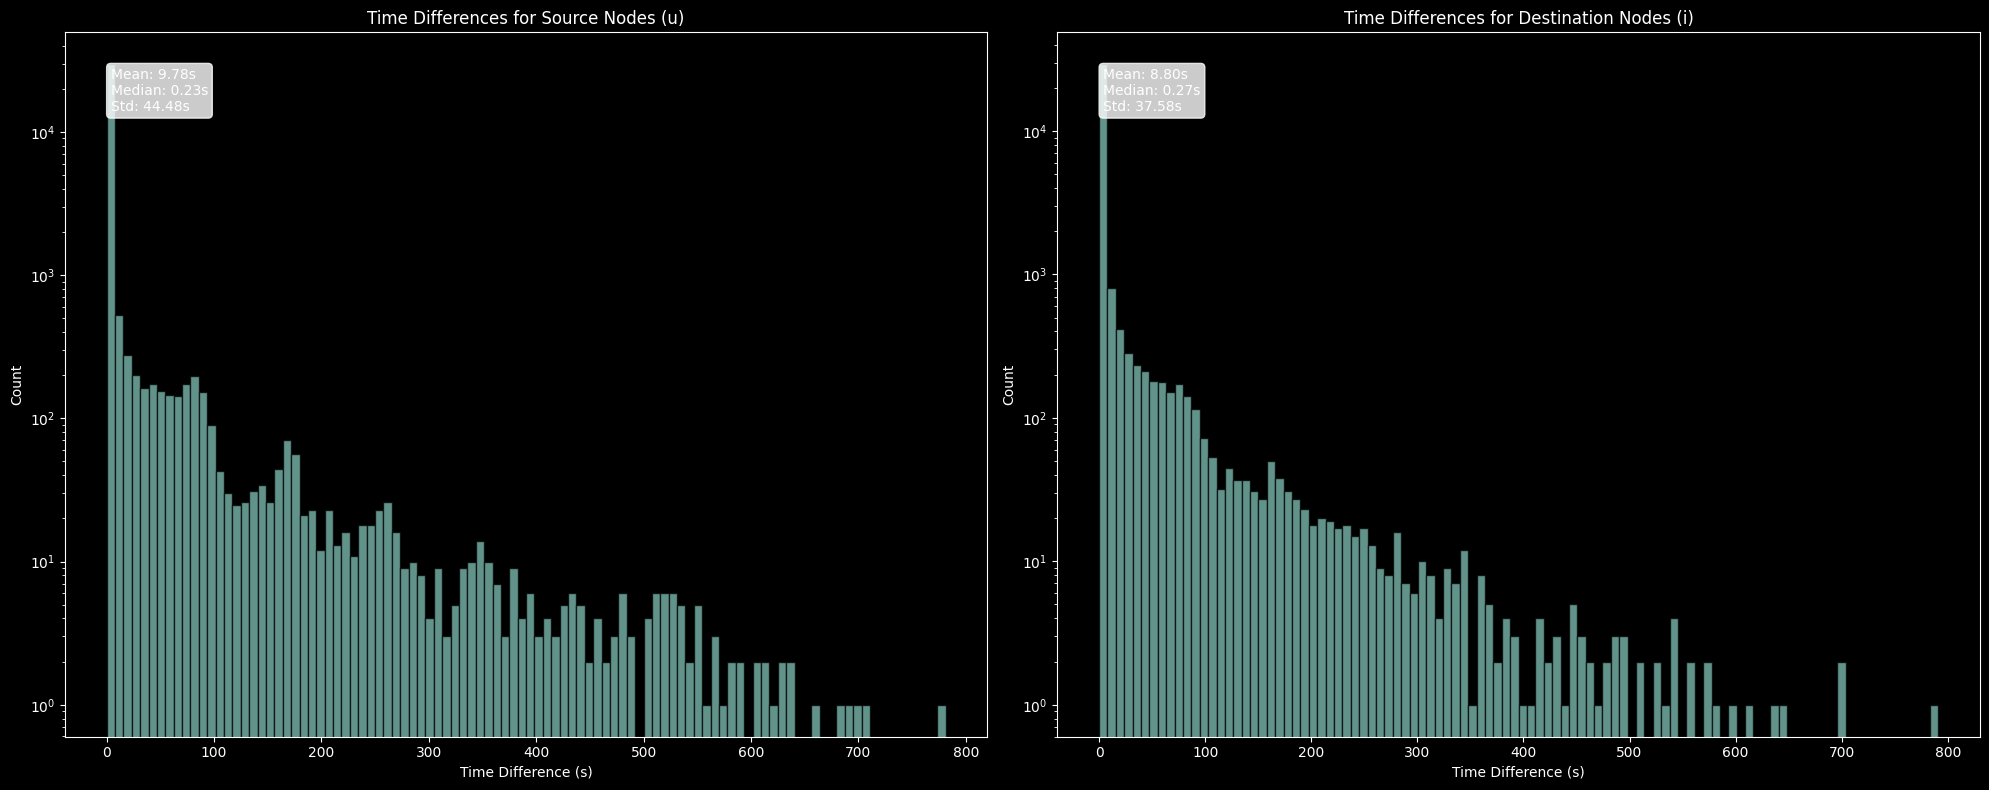

In [18]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot for source nodes (u)
ns_df_u = ns_df.sort_values(['u', 'ts'])
ns_df_u['diff'] = ns_df_u.groupby(['u'])['ts'].diff().fillna(0)
ts_diffs_u = ns_df_u['diff'].dropna()

ax1.hist(ts_diffs_u/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax1.set_ylabel('Count')
ax1.set_xlabel('Time Difference (s)')
ax1.set_title('Time Differences for Source Nodes (u)')

# Calculate and display statistics for u
mean_diff_u = ts_diffs_u.mean()
median_diff_u = ts_diffs_u.median()
std_diff_u = ts_diffs_u.std()

ax1.text(0.05, 0.95, f'Mean: {mean_diff_u/1e3:.2f}s\nMedian: {median_diff_u/1e3:.2f}s\nStd: {std_diff_u/1e3:.2f}s', 
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot for destination nodes (i)
ns_df_i = ns_df.sort_values(['i', 'ts'])
ns_df_i['diff'] = ns_df_i.groupby(['i'])['ts'].diff().fillna(0)
ts_diffs_i = ns_df_i['diff'].dropna()

ax2.hist(ts_diffs_i/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax2.set_ylabel('Count')
ax2.set_xlabel('Time Difference (s)')
ax2.set_title('Time Differences for Destination Nodes (i)')

# Calculate and display statistics for i
mean_diff_i = ts_diffs_i.mean()
median_diff_i = ts_diffs_i.median()
std_diff_i = ts_diffs_i.std()

ax2.text(0.05, 0.95, f'Mean: {mean_diff_i/1e3:.2f}s\nMedian: {median_diff_i/1e3:.2f}s\nStd: {std_diff_i/1e3:.2f}s', 
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

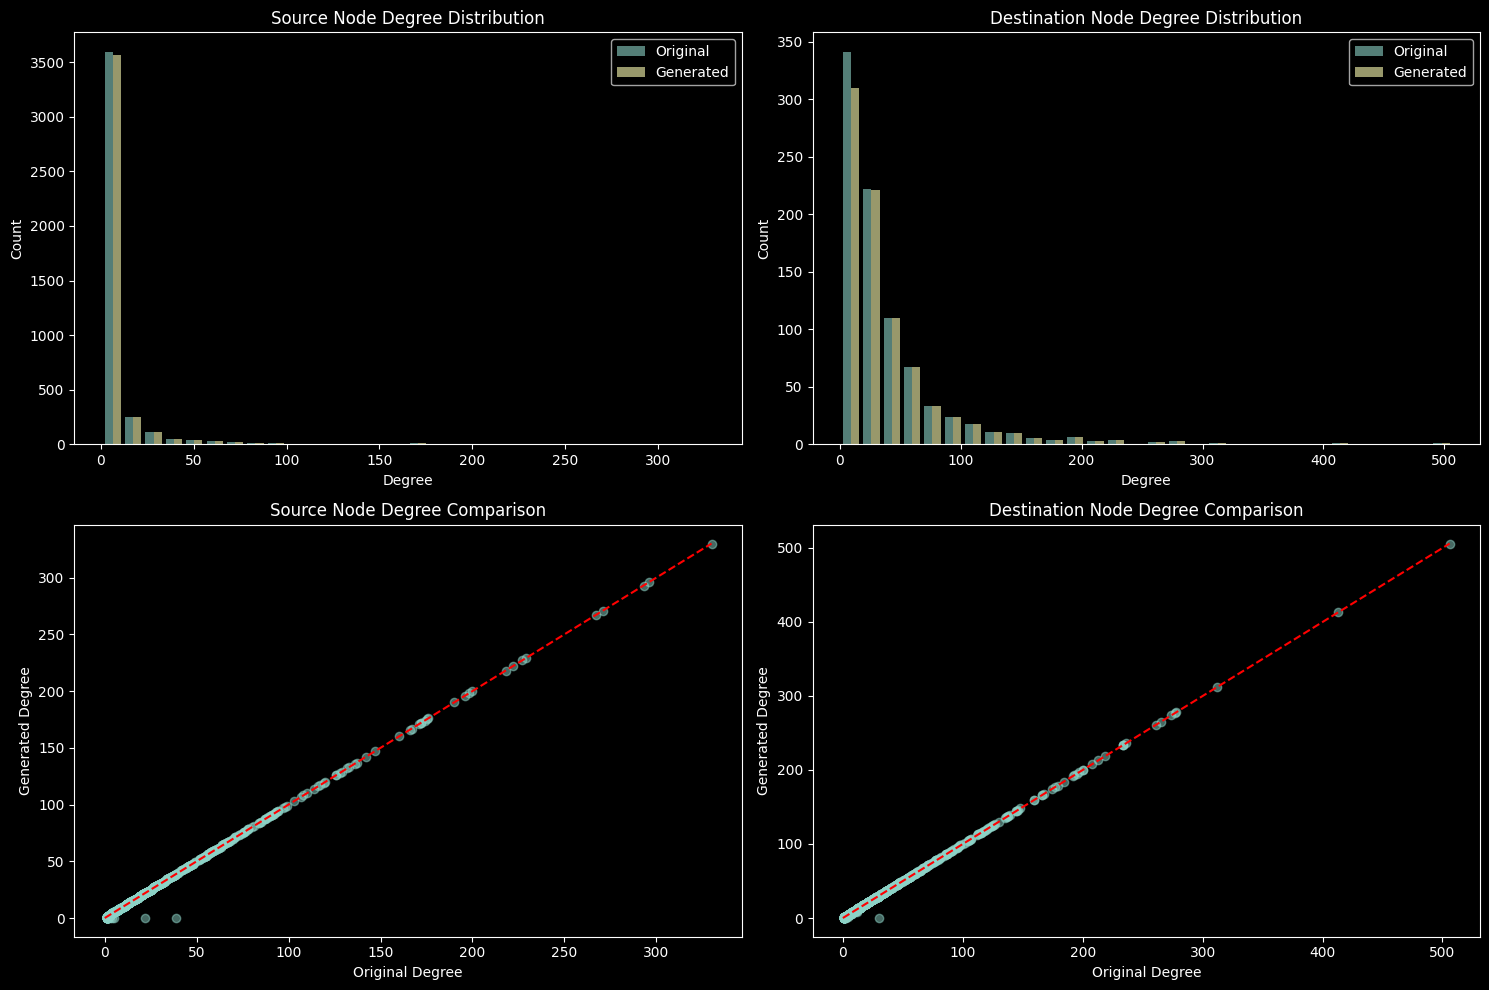

Source degree correlation: nan
Destination degree correlation: 1.000


In [19]:
def plot_degree_comparison(df1, df2, src_col='u', dst_col='i'):
    """
    Visualize degree distribution comparison between two DataFrames
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Calculate degree distributions
    src_degrees1 = Counter(df1[src_col])
    dst_degrees1 = Counter(df1[dst_col])
    src_degrees2 = Counter(df2[src_col])
    dst_degrees2 = Counter(df2[dst_col])
    
    # Plot 1: Source Node Degree Distribution
    degrees1 = list(src_degrees1.values())
    degrees2 = list(src_degrees2.values())
    ax1.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax1.set_title('Source Node Degree Distribution')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Count')
    ax1.legend()
    
    # Plot 2: Destination Node Degree Distribution
    degrees1 = list(dst_degrees1.values())
    degrees2 = list(dst_degrees2.values())
    ax2.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax2.set_title('Destination Node Degree Distribution')
    ax2.set_xlabel('Degree')
    ax2.set_ylabel('Count')
    ax2.legend()
    
    # Plot 3: Source Node Degree Scatter
    x = sorted(set(src_degrees1.keys()) | set(src_degrees2.keys()))
    y1 = [src_degrees1.get(k, 0) for k in x]
    y2 = [src_degrees2.get(k, 0) for k in x]
    ax3.scatter(y1, y2, alpha=0.5)
    ax3.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax3.set_title('Source Node Degree Comparison')
    ax3.set_xlabel('Original Degree')
    ax3.set_ylabel('Generated Degree')
    
    # Plot 4: Destination Node Degree Scatter
    x = sorted(set(dst_degrees1.keys()) | set(dst_degrees2.keys()))
    y1 = [dst_degrees1.get(k, 0) for k in x]
    y2 = [dst_degrees2.get(k, 0) for k in x]
    ax4.scatter(y1, y2, alpha=0.5)
    ax4.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax4.set_title('Destination Node Degree Comparison')
    ax4.set_xlabel('Original Degree')
    ax4.set_ylabel('Generated Degree')
    
    plt.tight_layout()
    plt.savefig("BP_degree_dist.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    
    # Additional statistics
    src_corr = np.corrcoef(
        [src_degrees1.get(k, 0) for k in x],
        [src_degrees2.get(k, 0) for k in x]
    )[0,1]
    dst_corr = np.corrcoef(
        [dst_degrees1.get(k, 0) for k in x],
        [dst_degrees2.get(k, 0) for k in x]
    )[0,1]
    
    print(f"Source degree correlation: {src_corr:.3f}")
    print(f"Destination degree correlation: {dst_corr:.3f}")

def plot_degree_comparison_nonbipartite(df1, df2, node_cols=['u', 'i']):
    """
    Visualize degree distribution comparison between two DataFrames for non-bipartite graphs
    
    Parameters:
    -----------
    df1, df2 : pandas.DataFrame
        DataFrames containing edge information
    node_cols : list
        Column names containing node IDs (default ['u', 'i'])
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Calculate unified degree distributions
    def get_degree_dist(df):
        degrees = Counter()
        for col in node_cols:
            degrees.update(Counter(df[col]))
        return degrees
    
    degrees1 = get_degree_dist(df1)
    degrees2 = get_degree_dist(df2)
    
    # Plot 1: Overall Node Degree Distribution
    degree_values1 = list(degrees1.values())
    degree_values2 = list(degrees2.values())
    
    ax1.hist([degree_values1, degree_values2], 
             label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax1.set_title('Node Degree Distribution')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Count')
    ax1.set_yscale('log')  # Log scale for better visualization
    ax1.legend()
    
    # Plot 2: Degree Comparison Scatter
    x = sorted(set(degrees1.keys()) | set(degrees2.keys()))
    y1 = [degrees1.get(k, 0) for k in x]
    y2 = [degrees2.get(k, 0) for k in x]
    
    # y2 = [val2 if val1 == val2 else val2 for val1, val2 in zip(y1, y2)]


    
    
    ax2.scatter(y1, y2, alpha=0.5)
    ax2.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax2.set_title('Node Degree Comparison')
    ax2.set_xlabel('Original Degree')
    ax2.set_ylabel('Generated Degree')
    ax2.set_xscale('log')  # Log scale for better visualization
    ax2.set_yscale('log')
    
    plt.tight_layout()
    # plt.savefig("NonBP_degree_dist.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    
    # Additional statistics
    degree_corr = np.corrcoef(y1, y2)[0,1]
    
    # Calculate degree statistics
    def degree_stats(degrees):
        values = list(degrees.values())
        return {
            'mean': np.mean(values),
            'median': np.median(values),
            'std': np.std(values),
            'max': max(values),
            'min': min(values)
        }
    
    stats1 = degree_stats(degrees1)
    stats2 = degree_stats(degrees2)
    
    print("\nDegree Distribution Statistics:")
    print(f"Degree correlation: {degree_corr:.3f}")
    print("\nOriginal Graph:")
    for k, v in stats1.items():
        print(f"{k}: {v:.2f}")
    print("\nGenerated Graph:")
    for k, v in stats2.items():
        print(f"{k}: {v:.2f}")
    
    # Calculate KL divergence for degree distributions
    def calculate_kl_divergence(p, q):
        # Normalize distributions
        p_sum = sum(p)
        q_sum = sum(q)
        p_norm = [x/p_sum for x in p]
        q_norm = [x/q_sum for x in q]
        
        # Add small constant to avoid division by zero
        epsilon = 1e-10
        p_norm = [x + epsilon for x in p_norm]
        q_norm = [x + epsilon for x in q_norm]
        
        return sum(p * np.log(p/q) for p, q in zip(p_norm, q_norm))
    
    kl_div = calculate_kl_divergence(np.array(y1), np.array(y2))
    print(f"\nKL Divergence: {kl_div:.3f}")
    

# use
if is_bipartite:
    plot_degree_comparison(all_missing_edges, ns_df)
else:
    plot_degree_comparison_nonbipartite(all_missing_edges, ns_df)

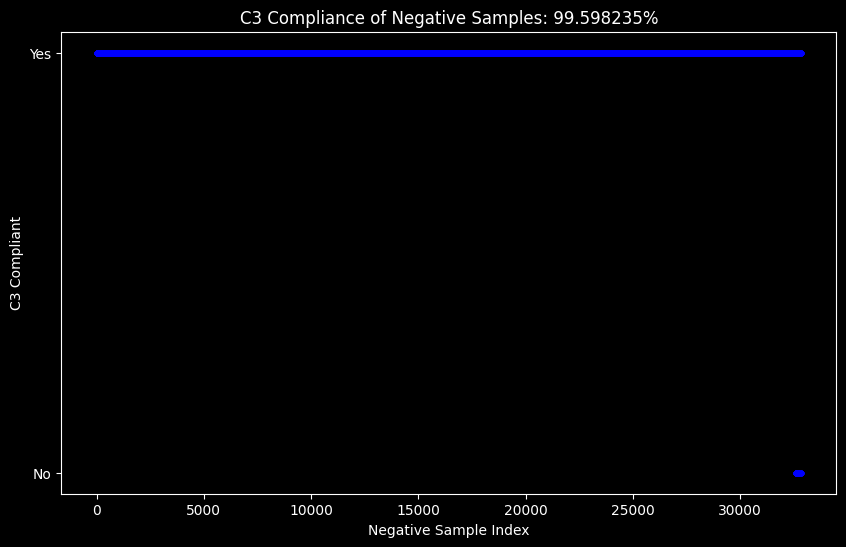

In [20]:
compliant = check_c3_compliance_optimized(all_missing_edges, new_edges)

plt.figure(figsize=(10, 6))
plt.plot(range(len(compliant)), compliant, 'b.')
plt.xlabel('Negative Sample Index')
plt.ylabel('C3 Compliant')
plt.title(f'C3 Compliance of Negative Samples: {sum(compliant)/len(compliant):.6%}')
plt.yticks([0, 1], ['No', 'Yes'])
plt.savefig("C3_Compliant.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [21]:
# import pandas as pd
# import numpy as np
# from collections import defaultdict
# from typing import List, Dict, Tuple, Set, Optional

# # This is the unseen function that prepares 'node_appearances'.
# # Its logic MUST mirror NonBipartiteNegativeSampler._extract_node_timestamps
# def optimize_c3_checking(df: pd.DataFrame) -> Dict[int, np.ndarray]:
#     """
#     Prepares node_appearances dictionary from the original DataFrame.
#     CRITICAL: This function's logic for extracting and processing timestamps
#     (float precision, sorting, uniqueness) must be IDENTICAL to
#     NonBipartiteNegativeSampler._extract_node_timestamps.
#     The input 'df' must be IDENTICAL to 'original_df' passed to the sampler.
#     """
#     node_timestamps_dict: Dict[int, List[float]] = defaultdict(list)
    
#     # Determine column names, robustly checking common alternatives
#     ts_col_name = None
#     if 'ts' in df.columns:
#         ts_col_name = 'ts'
#     elif df.index.name == 'ts': # Check if 'ts' is the name of the index
#         ts_col_name = df.index.name 
    
#     u_col_name = 'u' if 'u' in df.columns else 'source'
#     v_col_name = 'i' if 'i' in df.columns else ('v' if 'v' in df.columns else 'target')

#     for idx, row_series in df.iterrows():
#         row = row_series.to_dict() if isinstance(row_series, pd.Series) else row_series
        
#         raw_ts = idx if ts_col_name == df.index.name else row.get(ts_col_name)
#         if raw_ts is None:
#             # print(f"Warning: Missing timestamp in row: {row}") # Optional debug
#             continue
#         try:
#             ts = float(raw_ts) 
#         except ValueError:
#             # print(f"Warning: Could not convert timestamp '{raw_ts}' to float in row: {row}") # Optional debug
#             continue

#         u_val = row.get(u_col_name)
#         v_val = row.get(v_col_name)

#         if u_val is None or v_val is None:
#             # print(f"Warning: Missing node ID in row: {row}") # Optional debug
#             continue
#         try:
#             u, v = int(u_val), int(v_val)
#         except ValueError:
#             # print(f"Warning: Could not convert node IDs '{u_val}', '{v_val}' to int in row: {row}") # Optional debug
#             continue
            
#         node_timestamps_dict[u].append(ts)
#         node_timestamps_dict[v].append(ts)
    
#     node_timestamps_np: Dict[int, np.ndarray] = {}
#     for node_id_int in node_timestamps_dict:
#         if node_timestamps_dict[node_id_int]: # Ensure list is not empty before creating array
#             unique_sorted_ts = np.array(sorted(list(set(node_timestamps_dict[node_id_int]))), dtype=float)
#             node_timestamps_np[node_id_int] = unique_sorted_ts
#         else:
#             node_timestamps_np[node_id_int] = np.array([], dtype=float) # Empty array if no timestamps
            
#     return node_timestamps_np


# def fast_check_c3_compliance(
#     node_appearances: Dict[int, np.ndarray], 
#     negative_samples: List[Tuple[int, int, float]], 
#     time_window: float # CRITICAL: This value MUST match the sampler's effective self.time_window_internal
#                       # e.g., if sampler uses 1200000.0 (ms), this should also be 1200000.0
#     ) -> List[bool]:
#     """
#     Fast C3 compliance checking using binary search (asymmetric window).
    
#     Args:
#         node_appearances: Dict mapping node IDs to sorted numpy arrays of their float timestamps.
#         negative_samples: List/array of (u, i, ts) tuples to check (ts should be float).
#         time_window: Effective time window size (e.g., in milliseconds), matching the sampler's.
#     """
#     compliant_mask = []
    
#     for u_node, i_node, ts_candidate in negative_samples:
#         u = int(u_node)
#         i = int(i_node)
#         ts = float(ts_candidate) # Ensure ts is float for comparison

#         # Check source node u
#         u_times = node_appearances.get(u, np.array([])) # Default to empty array if node not in appearances
#         if len(u_times) == 0:
#             compliant_mask.append(False)
#             continue
            
#         window_start_u = ts - time_window
#         # Find first original timestamp for u that is >= window_start_u
#         u_idx = np.searchsorted(u_times, window_start_u, side='left') 
        
#         # Check if that timestamp is within the window [ts - time_window, ts]
#         if not (u_idx < len(u_times) and u_times[u_idx] <= ts):
#             compliant_mask.append(False)
#             continue
            
#         # Check destination node i
#         i_times = node_appearances.get(i, np.array([])) # Default to empty array
#         if len(i_times) == 0:
#             compliant_mask.append(False)
#             continue
            
#         window_start_i = ts - time_window
#         # Find first original timestamp for i that is >= window_start_i
#         i_idx = np.searchsorted(i_times, window_start_i, side='left')
        
#         # Check if that timestamp is within the window [ts - time_window, ts]
#         if not (i_idx < len(i_times) and i_times[i_idx] <= ts):
#             compliant_mask.append(False)
#             continue
            
#         compliant_mask.append(True) # Both nodes are C3 compliant for this (u,i,ts)
        
#     return compliant_mask

# def check_c3_compliance_optimized_wrapper(
#     original_df_for_checker: pd.DataFrame, # CRITICAL: Must be identical to sampler's original_df
#     negative_samples_output: List[Tuple[int, int, float]], # Output from the sampler
#     effective_time_window_value: float # CRITICAL: Must match sampler's self.time_window_internal
#     ) -> Tuple[float, List[bool]]:
#     """
#     Wrapper for optimized C3 checking.
#     Ensures consistent data preparation and parameter usage.
#     """
#     print(f"External C3 Checker: Using effective time window: {effective_time_window_value}")
    
#     # 1. Prepare node_appearances (mirroring sampler's _extract_node_timestamps)
#     # CRITICAL: 'original_df_for_checker' must be the same as used by the sampler.
#     node_appearances_for_checker = optimize_c3_checking(original_df_for_checker)
    
#     # 2. Check compliance using the exact same effective time_window
#     # CRITICAL: 'effective_time_window_value' must be the same as sampler's self.time_window_internal.
#     compliance_results = fast_check_c3_compliance(
#         node_appearances_for_checker, 
#         negative_samples_output, 
#         time_window=effective_time_window_value
#     )
    
#     compliance_percentage = (sum(compliance_results) / len(compliance_results)) * 100 if compliance_results else 0
#     print(f"External C3 Compliance: {compliance_percentage:.2f}%")
    
#     return compliance_percentage, compliance_results


# # Now, check C3 compliance using the external checker
# # CRITICAL: Use the *same* full_original_df
# # CRITICAL: Calculate the effective time window used by the sampler
# # If sampler takes time_window in seconds and converts to ms by *1000:
# effective_window_for_checker = 1200 * 1000.0 # This should match sampler.time_window_internal

# compliance_percentage, _ = check_c3_compliance_optimized_wrapper(
#     original_df_for_checker=all_missing_edges, 
#     negative_samples_output=new_edges,
#     effective_time_window_value=effective_window_for_checker 
# )
# print(f"Final External C3 Compliance: {compliance_percentage:.2f}%")


# # compliant = check_c3_compliance_optimized(all_missing_edges, new_edges)

# # plt.figure(figsize=(10, 6))
# # plt.plot(range(len(compliant)), compliant, 'b.')
# # plt.xlabel('Negative Sample Index')
# # plt.ylabel('C3 Compliant')
# # plt.title(f'C3 Compliance of Negative Samples: {sum(compliant)/len(compliant):.6%}')
# # plt.yticks([0, 1], ['No', 'Yes'])
# # plt.savefig("C3_Compliant.pdf", format="pdf", bbox_inches="tight")
# # plt.show()
